<a href="https://colab.research.google.com/github/Rajya-Kondisetti/AI-ML/blob/main/AIML_ML_Project_Full_Code_Notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Problem Statement

### Context

AllLife Bank is a mid-sized, fast-growing US-based financial institution that offers a range of retail banking services, including savings and checking accounts, fixed deposits, and personal loans. The bank’s business model is centered on building long-term customer relationships, expanding its retail footprint, and growing its loan portfolio to drive sustainable profitability through interest income.

It currently relies on a large base of liability customers (depositors) but faces a significant under-representation of asset customers (borrowers). To drive profitability through interest income, the bank must aggressively expand its loan portfolio by converting existing depositors into personal loan customers.

Last year’s pilot campaign achieved a 9% conversion rate, validating the potential of this strategy. However, to optimize marketing spend and improve efficiency, the retail marketing department requires a more data-driven approach. Enhancing the success ratio of these campaigns is critical for sustainable growth and maximizing customer lifetime value.

### Objective

The objective is to develop a predictive classification model that identifies patterns and key factors driving personal loan adoption among existing liability customers. By uncovering the demographic and behavioral drivers of loan conversion, the goal is to enable targeted segmentation and more precise marketing interventions that improve campaign conversion rates, optimize marketing spend, and enhance overall profitability through higher-quality loan portfolio growth.

### Data Dictionary

* `ID`: Customer ID
* `Age`: Customer’s age in completed years
* `Experience`: #years of professional experience
* `Income`: Annual income of the customer (in thousand dollars)
* `ZIP Code`: Home Address ZIP code.
* `Family`: the Family size of the customer
* `CCAvg`: Average spending on credit cards per month (in thousand dollars)
* `Education`: Education Level. 1: Undergrad; 2: Graduate;3: Advanced/Professional
* `Mortgage`: Value of house mortgage if any. (in thousand dollars)
* `Personal_Loan`: Did this customer accept the personal loan offered in the last campaign? (0: No, 1: Yes)
* `Securities_Account`: Does the customer have securities account with the bank? (0: No, 1: Yes)
* `CD_Account`: Does the customer have a certificate of deposit (CD) account with the bank? (0: No, 1: Yes)
* `Online`: Do customers use internet banking facilities? (0: No, 1: Yes)
* `CreditCard`: Does the customer use a credit card issued by any other Bank (excluding All life Bank)? (0: No, 1: Yes)

## Importing necessary libraries

In [ ]:
# Installing the libraries with the specified version.
!pip install numpy==2.0.2 pandas==2.2.2 matplotlib==3.10.0 seaborn==0.13.2 scikit-learn==1.6.1 sklearn-pandas==2.2.0 -q --user

**Note**:

1. After running the above cell, kindly restart the notebook kernel (for Jupyter Notebook) or runtime (for Google Colab), write the relevant code for the project from the next cell, and run all cells sequentially from the next cell.

2. On executing the above line of code, you might see a warning regarding package dependencies. This error message can be ignored as the above code ensures that all necessary libraries and their dependencies are maintained to successfully execute the code in this notebook.

In [ ]:
# import libraries for data manipulation
import numpy as np
import pandas as pd

# import libraries for data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# to split data into training and test sets
from sklearn.model_selection import train_test_split

# to build decision tree model
from sklearn.tree import DecisionTreeClassifier
from sklearn import tree

# to tune different models
from sklearn.model_selection import GridSearchCV

# to compute classification metrics
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    recall_score,
    precision_score,
    f1_score,
)

## Loading the dataset

In [ ]:
# uncomment and run the below code snippets if the dataset is present in the Google Drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# loading data into a pandas dataframe
loan_campaign = pd.read_csv("/content/drive/MyDrive/Python/Loan_Modelling.csv")

In [ ]:
# creating a copy of the data
data = loan_campaign.copy()

 ## Data Overview

### Viewing the first and last 5 rows of the dataset

In [ ]:
data.head(5)

,ID,Age,Experience,Income,ZIPCode,Family,CCAvg,Education,Mortgage,Personal_Loan,Securities_Account,CD_Account,Online,CreditCard
0,1,25,1,49,91107,4,1.6,1,0,0,1,0,0,0
1,2,45,19,34,90089,3,1.5,1,0,0,1,0,0,0
2,3,39,15,11,94720,1,1.0,1,0,0,0,0,0,0
3,4,35,9,100,94112,1,2.7,2,0,0,0,0,0,0
4,5,35,8,45,91330,4,1.0,2,0,0,0,0,0,1


In [ ]:
data.tail(5)

,ID,Age,Experience,Income,ZIPCode,Family,CCAvg,Education,Mortgage,Personal_Loan,Securities_Account,CD_Account,Online,CreditCard
4995,4996,29,3,40,92697,1,1.9,3,0,0,0,0,1,0
4996,4997,30,4,15,92037,4,0.4,1,85,0,0,0,1,0
4997,4998,63,39,24,93023,2,0.3,3,0,0,0,0,0,0
4998,4999,65,40,49,90034,3,0.5,2,0,0,0,0,1,0
4999,5000,28,4,83,92612,3,0.8,1,0,0,0,0,1,1


### Checking the shape of the dataset

In [ ]:
data.shape

(5000, 14)

*   The dataset has 5000 rows and 14 columns




### Checking the attribute types

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   ID                  5000 non-null   int64  
 1   Age                 5000 non-null   int64  
 2   Experience          5000 non-null   int64  
 3   Income              5000 non-null   int64  
 4   ZIPCode             5000 non-null   int64  
 5   Family              5000 non-null   int64  
 6   CCAvg               5000 non-null   float64
 7   Education           5000 non-null   int64  
 8   Mortgage            5000 non-null   int64  
 9   Personal_Loan       5000 non-null   int64  
 10  Securities_Account  5000 non-null   int64  
 11  CD_Account          5000 non-null   int64  
 12  Online              5000 non-null   int64  
 13  CreditCard          5000 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 547.0 KB


*   All the 14 variables are numerical in the dataset.
*   ZIPcode should be a categorical variable.
*  Education is also a Categoricfal variable but it is described with numerical digits .
*   Personal_Loan, Securities_Account, CD_Account, Online and Credit card, although interpreted here as numerical, are categorical variables that are encoded by default.



### Checking the statistical summary

In [ ]:
#code to print the statistical summary of the data
data.describe(include='all').T

,count,mean,std,min,25%,50%,75%,max
ID,5000.0,2500.500000,1443.520003,1.0,1250.75,2500.5,3750.25,5000.0
Age,5000.0,45.338400,11.463166,23.0,35.00,45.0,55.00,67.0
Experience,5000.0,20.104600,11.467954,-3.0,10.00,20.0,30.00,43.0
Income,5000.0,73.774200,46.033729,8.0,39.00,64.0,98.00,224.0
ZIPCode,5000.0,93169.257000,1759.455086,90005.0,91911.00,93437.0,94608.00,96651.0
Family,5000.0,2.396400,1.147663,1.0,1.00,2.0,3.00,4.0
CCAvg,5000.0,1.937938,1.747659,0.0,0.70,1.5,2.50,10.0
Education,5000.0,1.881000,0.839869,1.0,1.00,2.0,3.00,3.0
Mortgage,5000.0,56.498800,101.713802,0.0,0.00,0.0,101.00,635.0
Personal_Loan,5000.0,0.096000,0.294621,0.0,0.00,0.0,0.00,1.0


- The minimum professional experience is shown as '-3' years, this can't be right. It could've been a human error which needs to be updated.
- The average age of existing customers is ~45 years.
- On average, the customers have 20 years of professional experience.
- Applicants earn ~73k dollars annually, with ~25% earning more than $100k annually.
- On average the family size is 2 memebrs.
- The average spending on credit cards per month is around 1.9k dollars, with the maximum being around 10K dollars per month.
- The average house mortgage is around 56k dollars.
- 9% of customers accepted the personal loan offered in the last campaign.
- 10% of the customers have a securities account with the bank.
- 6% of the customers have a certificate of deposit (CD) account with the bank.
- 59% of customers use internet banking facilities.
- 29% of the customers use a credit card issued by other banks.



### Checking for missing values

In [ ]:
# Checking for missing values in the data
data.isnull().sum()

,0
ID,0
Age,0
Experience,0
Income,0
ZIPCode,0
Family,0
CCAvg,0
Education,0
Mortgage,0
Personal_Loan,0


*   There are no missing values in the data



### Checking for duplicate values

In [ ]:
# checking for duplicate values
data.duplicated().sum()

np.int64(0)

*   There are no duplicate values in the data.




### Dropping ID Column

In [ ]:
# Dropping ID as it a unqiue identifier with no predicitve value
data = data.drop('ID', axis=1)

In [ ]:
# Code to view the first 5 rows of the updated dataset
data.head(5)

,Age,Experience,Income,ZIPCode,Family,CCAvg,Education,Mortgage,Personal_Loan,Securities_Account,CD_Account,Online,CreditCard
0,25,1,49,91107,4,1.6,1,0,0,1,0,0,0
1,45,19,34,90089,3,1.5,1,0,0,1,0,0,0
2,39,15,11,94720,1,1.0,1,0,0,0,0,0,0
3,35,9,100,94112,1,2.7,2,0,0,0,0,0,0
4,35,8,45,91330,4,1.0,2,0,0,0,0,0,1


### Updating the Experience column

In [ ]:
#Checking the unqiue values in the Experience column
data['Experience'].unique()

array([ 1, 19, 15,  9,  8, 13, 27, 24, 10, 39,  5, 23, 32, 41, 30, 14, 18,
       21, 28, 31, 11, 16, 20, 35,  6, 25,  7, 12, 26, 37, 17,  2, 36, 29,
        3, 22, -1, 34,  0, 38, 40, 33,  4, -2, 42, -3, 43])

*   There are values such as -1, -2 & -3 which could be a human error and needs to be updated to 1, 2 & 3.





In [ ]:
# Code to update the Experience column
data['Experience'] = data['Experience'].replace(-1, 1)
data['Experience'] = data['Experience'].replace(-2, 2)
data['Experience'] = data['Experience'].replace(-3, 3)

#Code to see the unique values after updating the negative values
data['Experience'].unique()

array([ 1, 19, 15,  9,  8, 13, 27, 24, 10, 39,  5, 23, 32, 41, 30, 14, 18,
       21, 28, 31, 11, 16, 20, 35,  6, 25,  7, 12, 26, 37, 17,  2, 36, 29,
        3, 22, 34,  0, 38, 40, 33,  4, 42, 43])

### Converting ZIP codes & other categorical variables to category datatype

In [ ]:
# Code to get the number of unique zip codes in the dataset
data["ZIPCode"].nunique()

467

In [ ]:
# Code to take convert the zipcode to string datatype
data["ZIPCode"] = data["ZIPCode"].astype(str)
print("Count of unique zipcodes when we take first two digits of ZIPCode:",data["ZIPCode"].str[0:2].nunique())

# Code to update the ZIPCode column with the first two digits of the original zipcode
data["ZIPCode"] = data["ZIPCode"].str[0:2]

Count of unique zipcodes when we take first two digits of ZIPCode: 7


In [ ]:
# Code to see the unique zip codes in the dataset
data["ZIPCode"].unique()

array(['91', '90', '94', '92', '93', '95', '96'], dtype=object)

In [ ]:
# Convert all the categorical variables to category data type for decision tree modelling
category_col = ['Education', 'Personal_Loan', 'Securities_Account', 'CD_Account', "Online", 'CreditCard', 'ZIPCode']
data[category_col] = data[category_col].astype("category")

In [ ]:
# Code to see the updated daatypes of the columns
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype   
---  ------              --------------  -----   
 0   Age                 5000 non-null   int64   
 1   Experience          5000 non-null   int64   
 2   Income              5000 non-null   int64   
 3   ZIPCode             5000 non-null   category
 4   Family              5000 non-null   int64   
 5   CCAvg               5000 non-null   float64 
 6   Education           5000 non-null   category
 7   Mortgage            5000 non-null   int64   
 8   Personal_Loan       5000 non-null   category
 9   Securities_Account  5000 non-null   category
 10  CD_Account          5000 non-null   category
 11  Online              5000 non-null   category
 12  CreditCard          5000 non-null   category
dtypes: category(7), float64(1), int64(5)
memory usage: 269.8 KB


*   Converted all the categorical variables to category datatype.




## Exploratory Data Analysis.

EDA is a critical step in any data project used to investigate and understand the data before model construction.

The following questions serve as a starting point to help you approach the analysis and generate initial insights:

**Questions**:
1. What is the distribution of mortgage attribute? Are there any noticeable patterns or outliers in the distribution?
2. How many customers have credit cards?
3. What are the attributes that have a strong correlation with the target attribute (personal loan)?
4. How does a customer's interest in purchasing a loan vary with their education?
5. How does a customer's interest in purchasing a loan vary with their age?

**[IMPORTANT]** Beyond the Basics: Please note that these are guiding questions only. To receive full points for this rubric section, you are expected to perform a thorough analysis that goes beyond these specific questions to uncover deeper trends and relationships within the data.

### Univariate Analysis

#### Observations on Numerical features

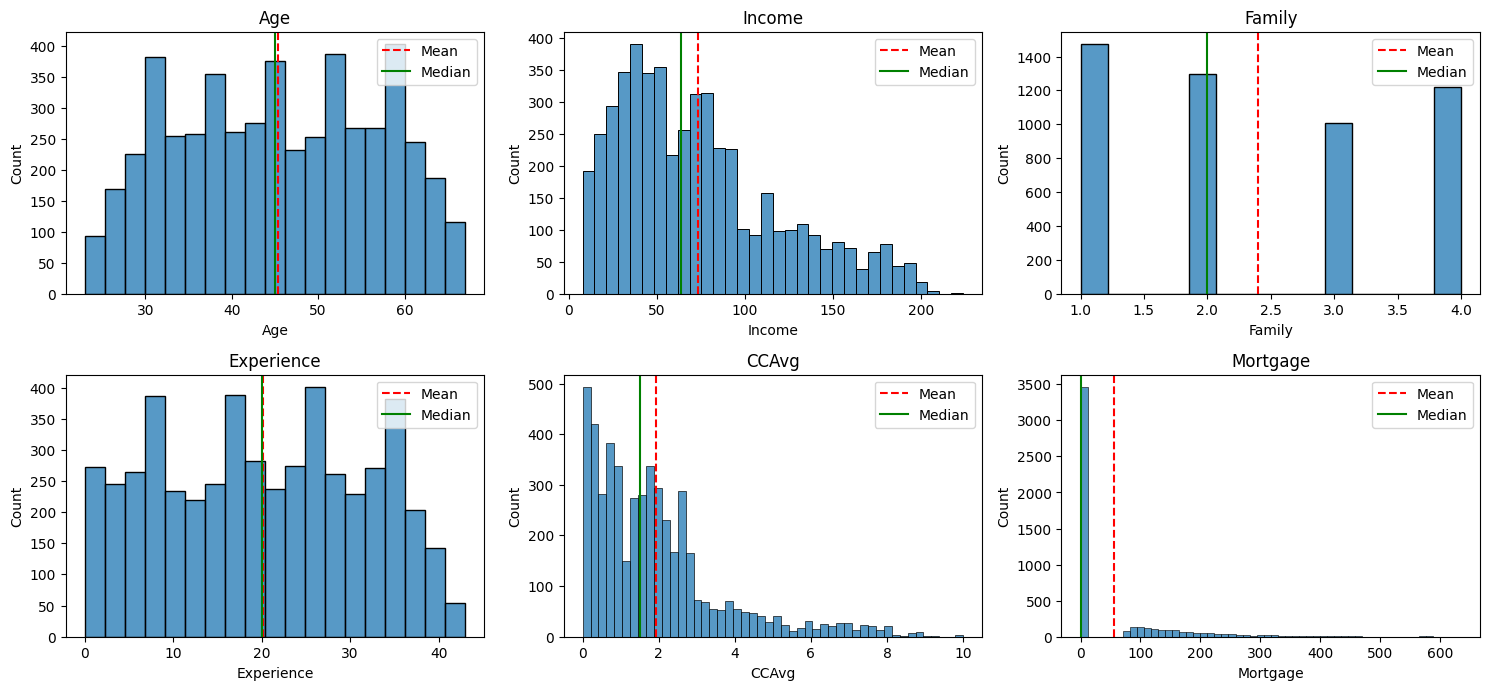

In [ ]:
#Histogram of numercial features

#defining the figure size
plt.figure(figsize=(15, 10))

#defining the list of numerical features to plot
num_features = ['Age', 'Income', 'Family', 'Experience', 'CCAvg', 'Mortgage']

#plotting the histogram for each numerical feature
for i, feature in enumerate(num_features):
    plt.subplot(3, 3, i+1)
    sns.histplot(data=data, x=feature)

    #calculate mean and median
    mean_val = data[feature].mean()
    median_val = data[feature].median()

    #plot mean and median lines
    plt.axvline(mean_val, color='red', linestyle='--', label='Mean')
    plt.axvline(median_val, color='green', linestyle='-', label='Median')

    plt.title(feature)
    plt.legend()

#to add spacing between plots
plt.tight_layout();

*   Income and CCAvg are highly right-skewed
*   From the Mortagage plot you can see around 3400 customers don't have mortgage
*   All the families of the customers are either 1, 2 3 or 4 members.
*   The distribution of Age & Experience look normal with almost the same mean and median.






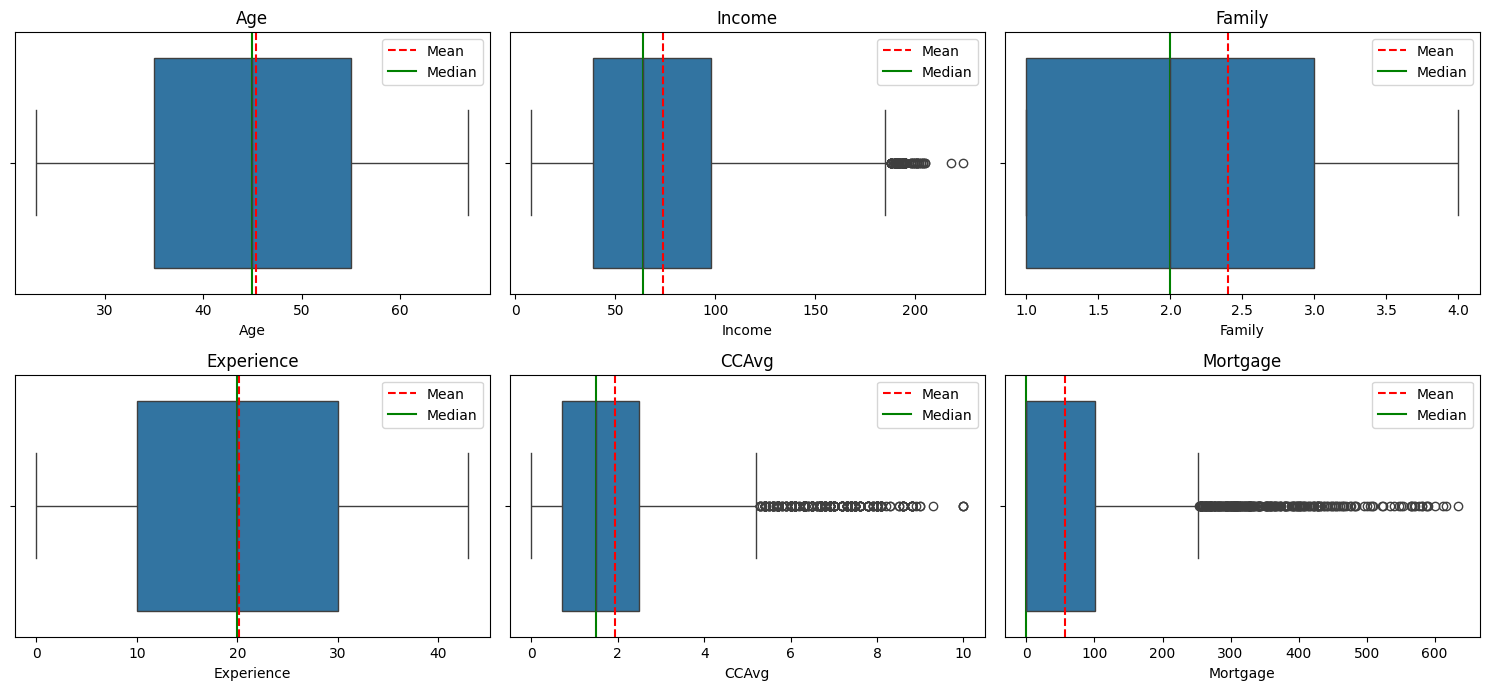

In [ ]:
#Boxplots of numerical features

# defining the figure size
plt.figure(figsize=(15, 10))

# plotting the boxplot for each numerical feature
for i, feature in enumerate(num_features):
    plt.subplot(3, 3, i+1)
    sns.boxplot(data=data, x=feature)

    #calculate mean and median
    mean_val = data[feature].mean()
    median_val = data[feature].median()

    #plot mean and median lines
    plt.axvline(mean_val, color='red', linestyle='--', label='Mean')
    plt.axvline(median_val, color='green', linestyle='-', label='Median')

    plt.title(feature)
    plt.legend()

plt.tight_layout();    # to add spacing between plots

*   The mean & median age of the customers is around 30 years.
*   The mean & median experience of customers is 20 years.
*   Each family has a median of 2 members.
*   CCAvg, Income and Mortgage have outliers.






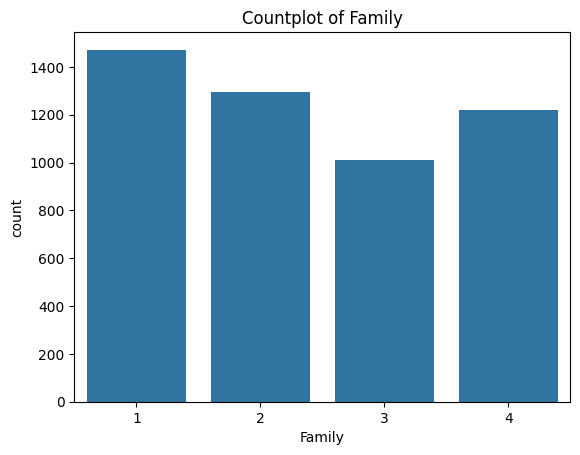

In [ ]:
#Countplot for Family
sns.countplot(data=data, x='Family')
plt.title('Countplot of Family')
plt.xlabel('Family')
plt.show()

####1. What is the distribution of mortgage attribute? Are there any noticeable patterns or outliers in the distribution?

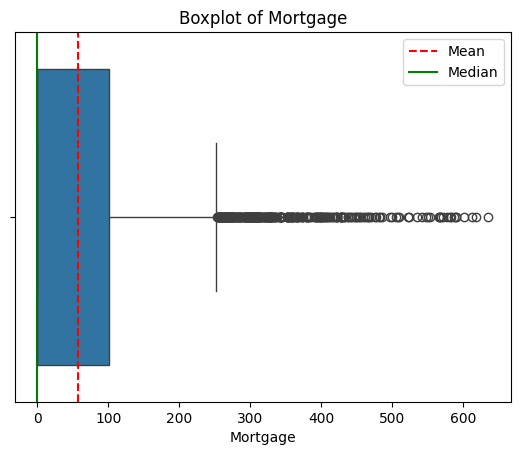

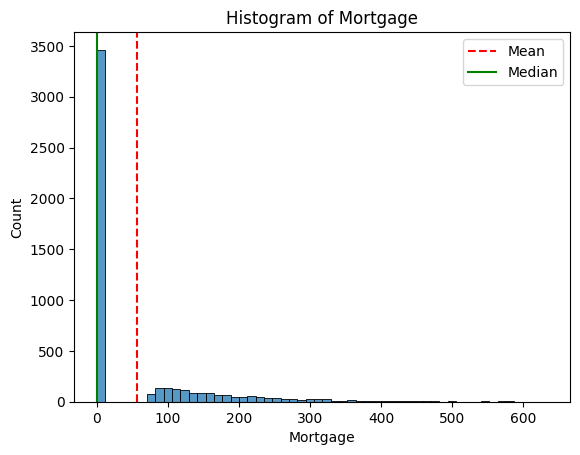

In [ ]:
#Boxplot & Histogram of Mortgage
sns.boxplot(data=data, x='Mortgage')
plt.title('Boxplot of Mortgage')
plt.axvline(mean_val, color='red', linestyle='--', label='Mean')
plt.axvline(median_val, color='green', linestyle='-', label='Median')
plt.xlabel('Mortgage')
plt.legend()
plt.show()

sns.histplot(data=data, x='Mortgage')
plt.title('Histogram of Mortgage')
plt.axvline(mean_val, color='red', linestyle='--', label='Mean')
plt.axvline(median_val, color='green', linestyle='-', label='Median')
plt.xlabel('Mortgage')
plt.legend()
plt.show()

*   The mortgag attribute is highly left skewed.
*   Around 3400 customers don't have a mortgage
*   The meadian of the mortgage is 0k dollars.
*   The median of the mortgage of customers is around 60-70k dollars.
*   Mortgage has outliers on the right side, indicating very large amounts of mortgage from 250k to 600 - 700k dollars.








####Observations on Categorical variables

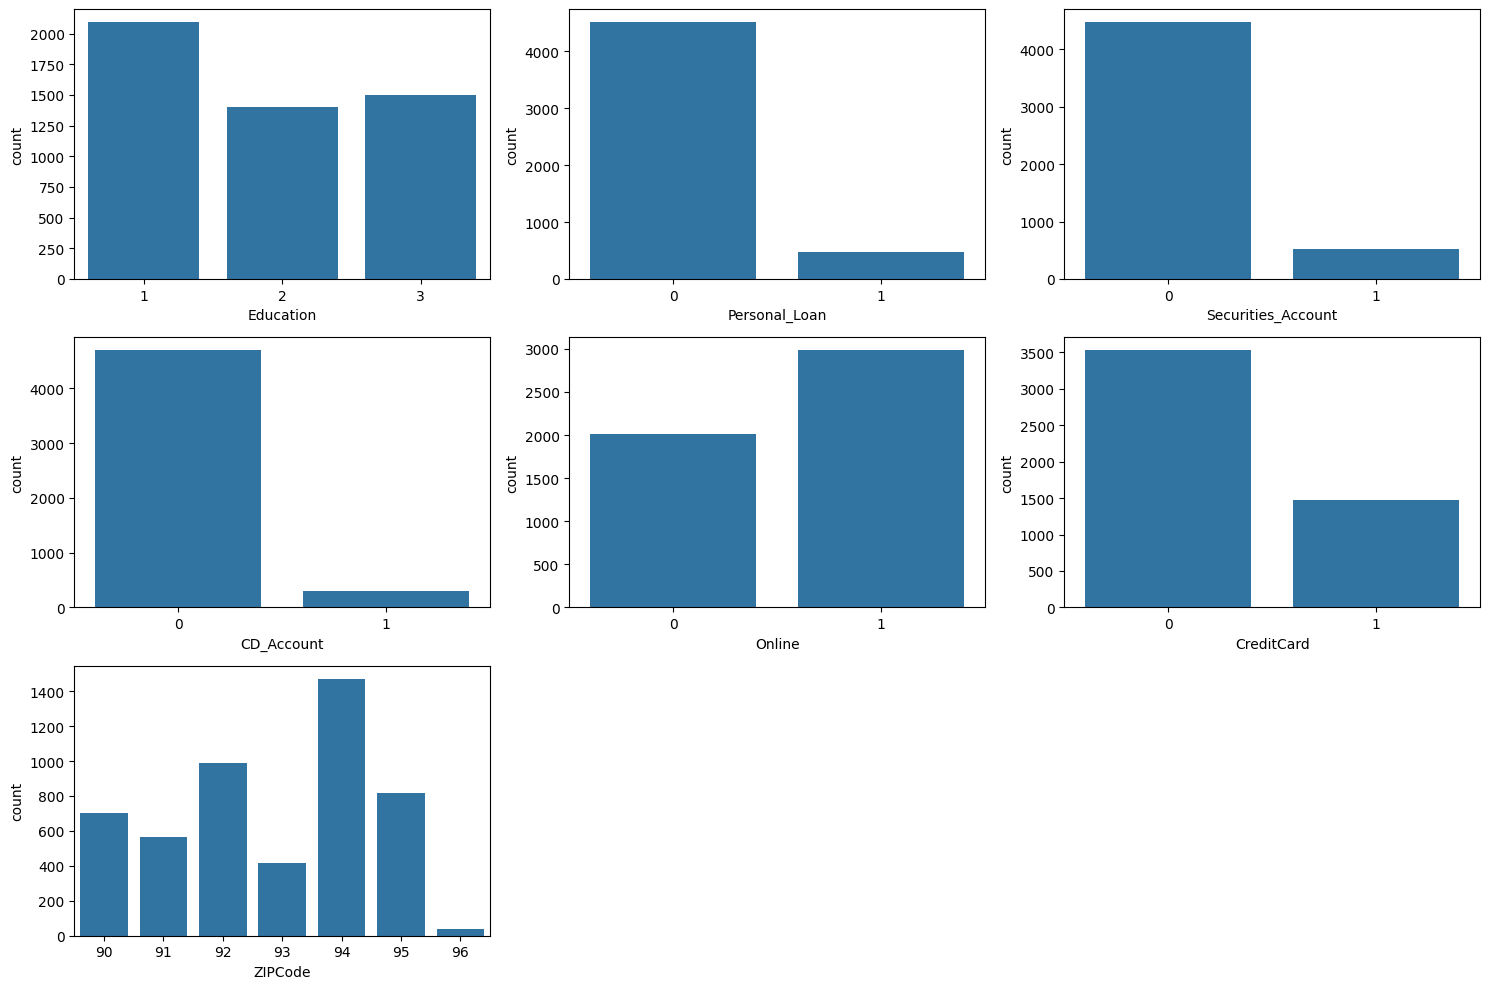

In [ ]:
# defining the figure size
plt.figure(figsize=(15, 10))

# plotting the countplots for each categorical feature
for i, feature in enumerate(category_col):
    plt.subplot(3, 3, i+1)
    sns.countplot(data=data, x=feature)

# to add spacing between plots
plt.tight_layout();


*   2000 plus customers only have an undergraduate degree out of the 5000 customers.
*   Less than 1000 customers have a Personal Loan from the bank.
*   Less than 1000 customers have a Securities accounf with the bank.
*   Less than 500 customers have a Certificate of deposit account with the bank.
*   More than 2500 customers use internet banking facilities.
*   More than 1000 customers have a CreditCard from other banks.
*   The most number of customers are from areas that have a zipcode that starts with "94".





####2. How many customers have credit cards?

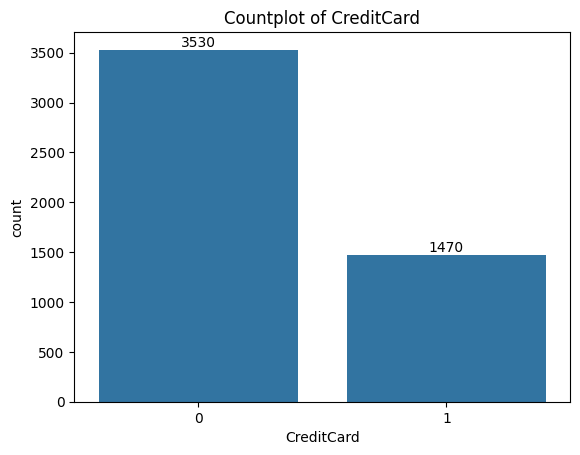

In [ ]:
# Countplot for CreditCard
cc = sns.countplot(data=data, x='CreditCard')

plt.title('Countplot of CreditCard')
plt.xlabel('CreditCard')

# Add counts on top of bars
for container in cc.containers:
    cc.bar_label(container)

plt.show()


*   1470 customers have a Credit cards that are issued by other banks.



### Bivariate Analysis

####3. What are the attributes that have a strong correlation with the target attribute (personal loan)?

<Figure size 1200x800 with 0 Axes>

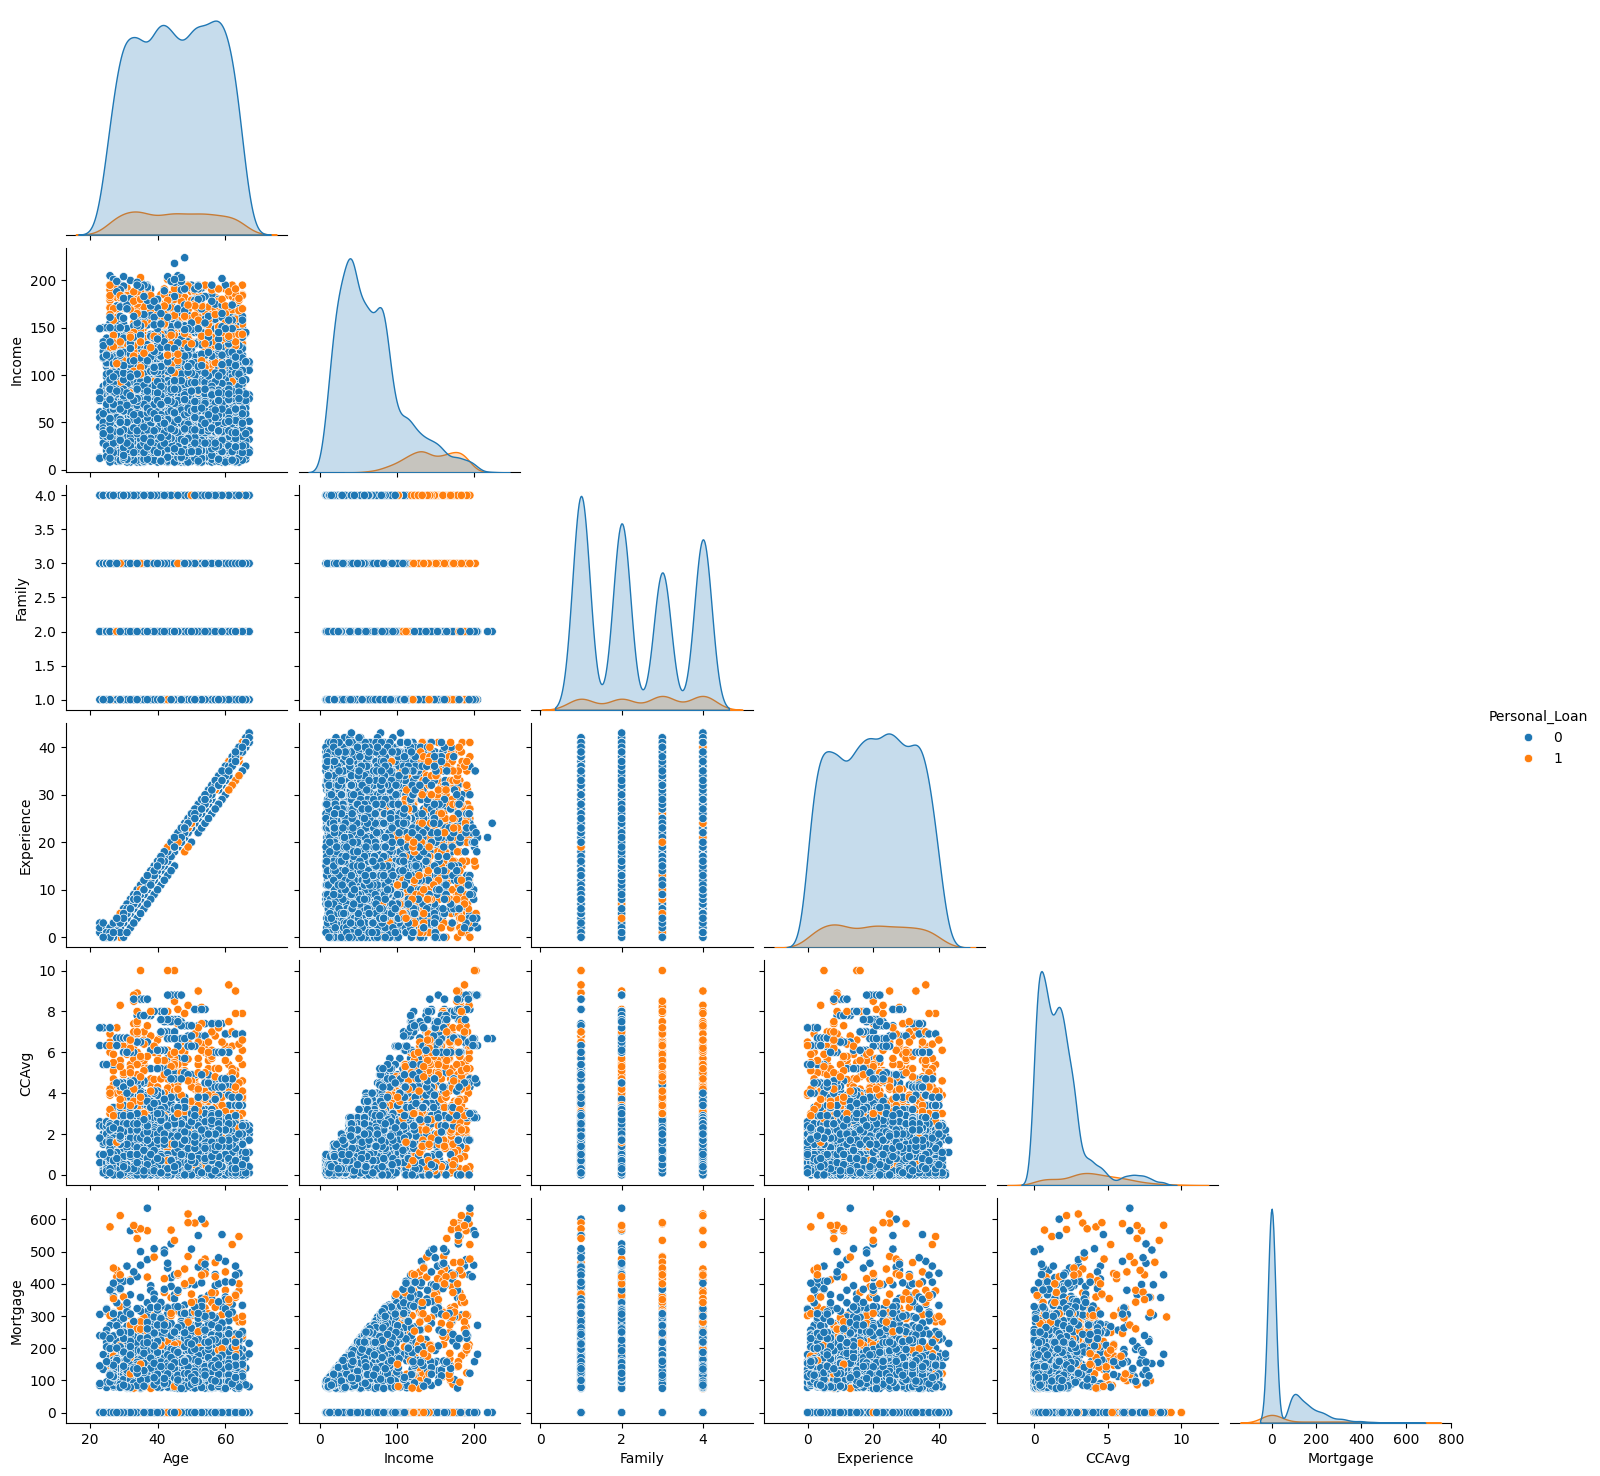

In [ ]:
# Scatter plot matrix
plt.figure(figsize=(12, 8))
sns.pairplot(data, vars=num_features, hue='Personal_Loan', diag_kind='kde', corner = True);
plt.show()

*   **Age & Experience does not appear to strongly influence loan acceptance but they are perfectly linearly related. Age and Experience have a very storng corelation with Personal Loan.**
*   Many orange points appear when income is high. Customers with higher income are more likely to take a personal loan.
*   Orange points are more concentrated in higher CCAvg values. Customers with higher credit card spending are more likely to take a loan.
*   Slightly more loan acceptance is visible for larger families (3–4). Family size might have a very small effect on Loan acceptance
*   Mortgage is spread across the values but looks like more orange points are at the high mortgage values. High mortgage might have a small effect on Loan acceptance.





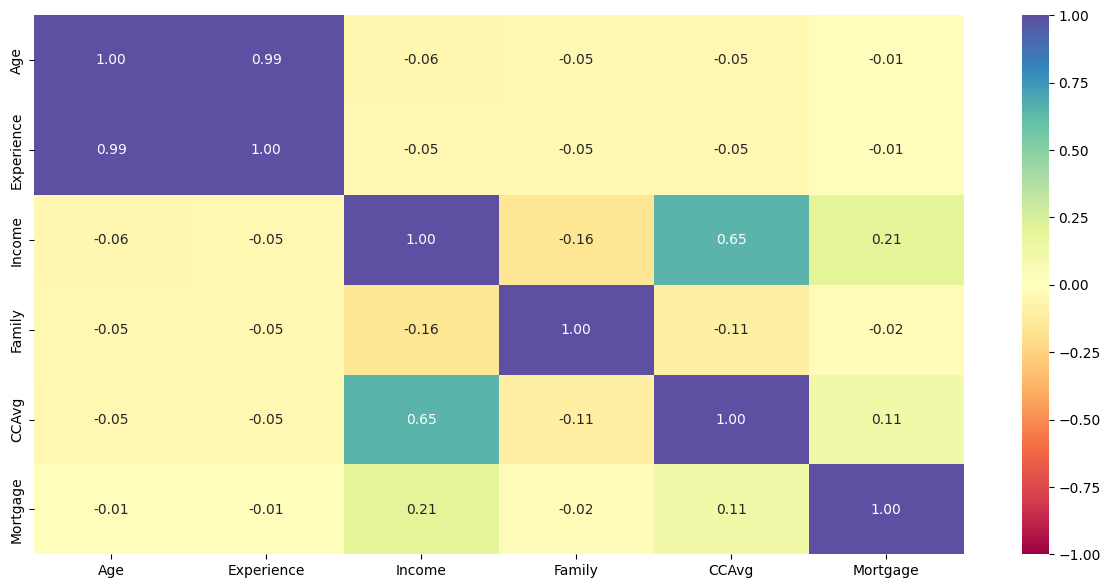

In [ ]:
#Heatmap of the numerical columns
plt.figure(figsize=(15, 7))
sns.heatmap(data.corr(numeric_only=True), annot=True, vmin=-1, vmax=1, fmt=".2f", cmap="Spectral")
plt.show()

*   **Age & Experience have a very strong positive correlation.**
*   One of them can be removed from the model to avoid multicollineraity.



####4. How does a customer's interest in purchasing a loan vary with their education?

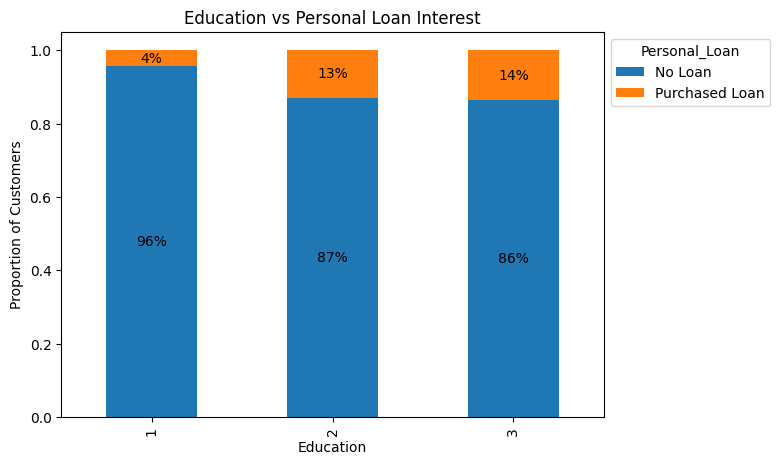

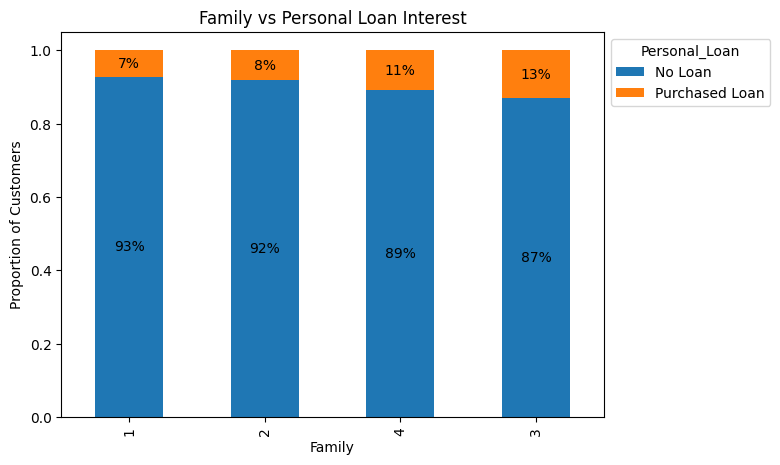

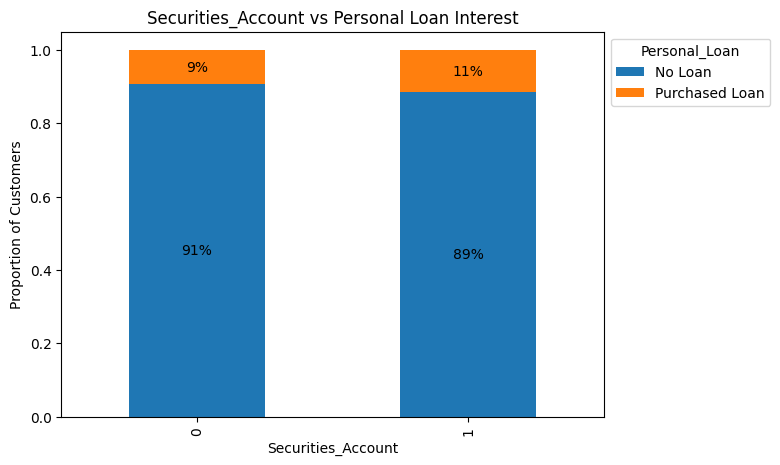

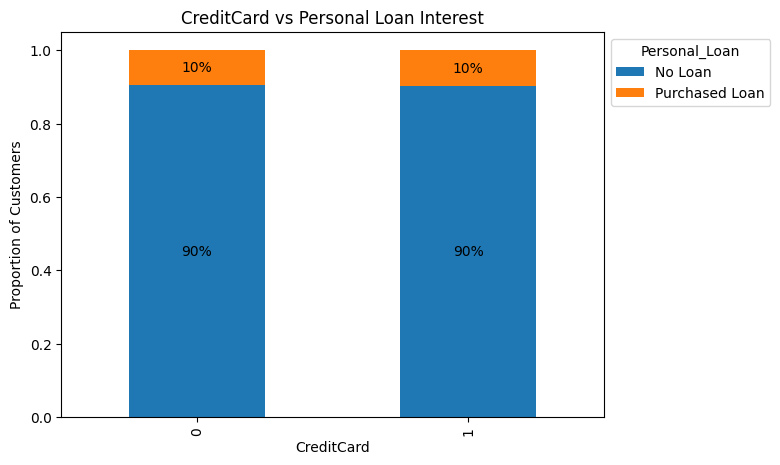

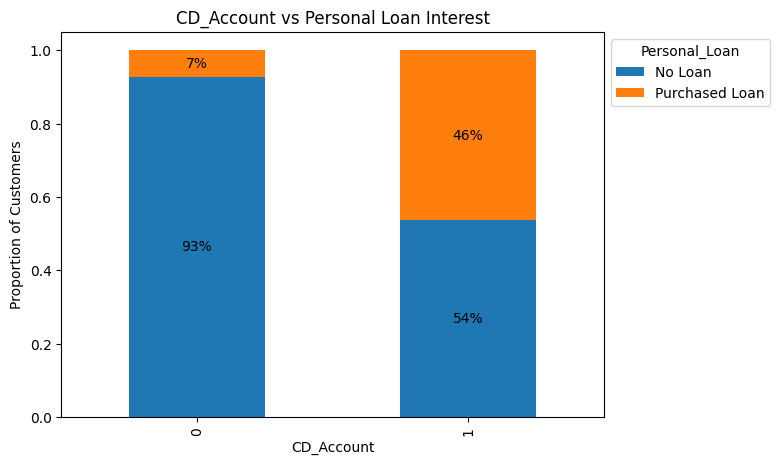

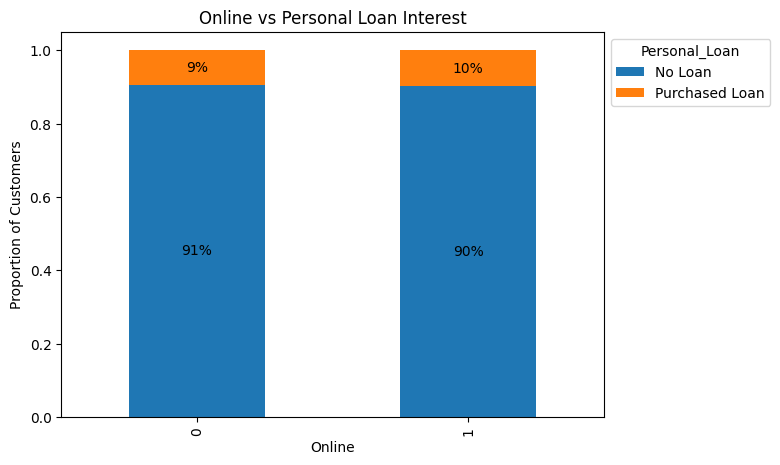

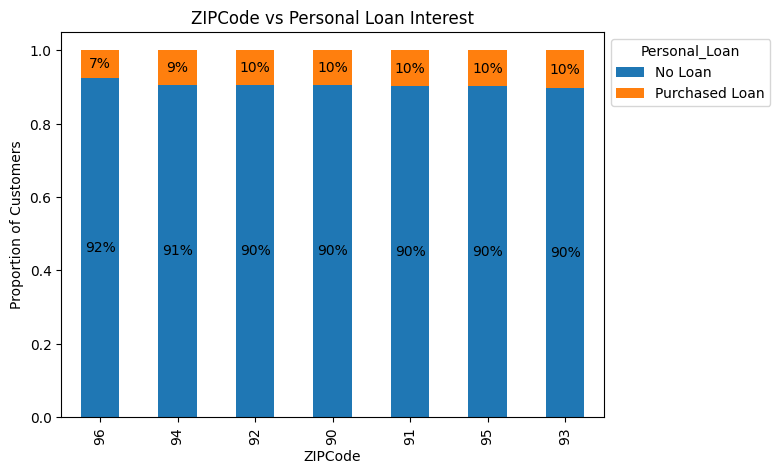

In [ ]:
# variables to analyze against Personal_Loan
features = ['Education', 'Family', 'Securities_Account', 'CreditCard', 'CD_Account', 'Online', 'ZIPCode']

for var in features:
    # Crosstab with percentages
    tab = pd.crosstab(data[var], data['Personal_Loan'], normalize='index').sort_values(by=1, ascending=True)

    # Plot stacked bar chart
    ax = tab.plot(kind='bar', stacked=True, figsize=(7,5))

    # Labels & title
    plt.xlabel(var)
    plt.ylabel("Proportion of Customers")
    plt.title(f'{var} vs Personal Loan Interest')
    plt.legend(title='Personal_Loan', labels=['No Loan', 'Purchased Loan'], loc='upper left', bbox_to_anchor=(1,1))

    # Show percentage on top of bars
    for p in ax.patches:
        height = p.get_height()
        if height > 0:
            ax.text(p.get_x() + p.get_width()/2., p.get_y() + height/2., f'{height:.0%}', ha="center", va="center", color="black")

    plt.show()

* **Customers with Grdauate and Advanced/Professional Education are the majority of customers who took the loan. Only 4% of undergraduate customers took a loan. Customers with higher degrees are more prone to take a loan.**
*   46% of the customers who had a CD_Account with the bank accepted the Personal Loan.



####5. How does a customer's interest in purchasing a loan vary with their age?

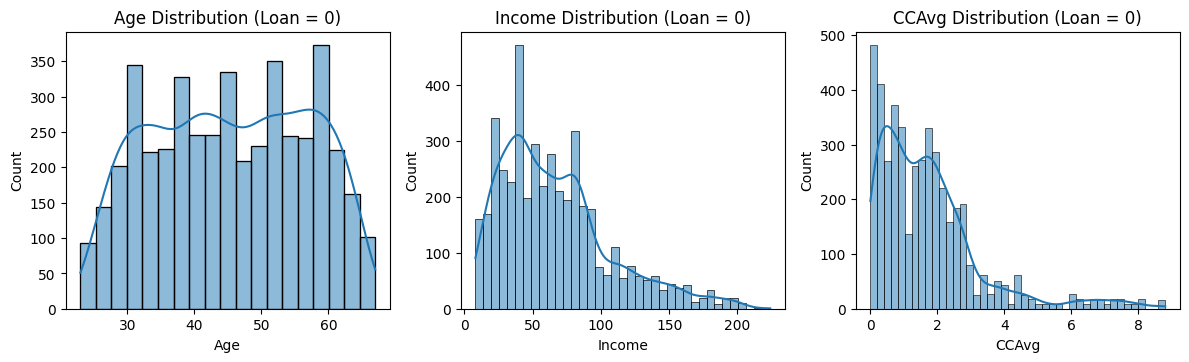

In [ ]:
plt.figure(figsize=(12, 10))

set = ['Age', 'Income', 'CCAvg']

#Histogram for Loan = 0
for i, feature in enumerate(set):
    plt.subplot(3, 3, i+1)
    sns.histplot(data=data[data['Personal_Loan'] == 0], x=feature, kde=True)
    plt.title(f"{feature} Distribution (Loan = 0)")

plt.tight_layout()
plt.show()


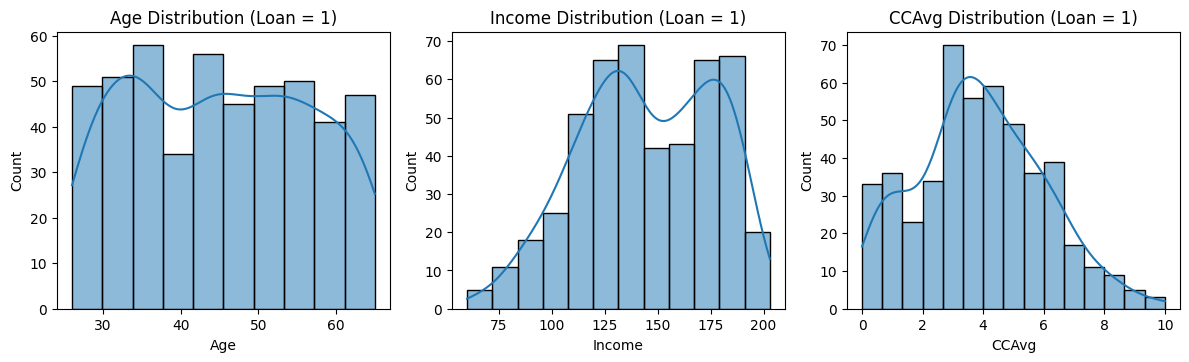

In [ ]:
#Histogram for Loan = 1

plt.figure(figsize=(12, 10))
for i, feature in enumerate(set):
    plt.subplot(3, 3, i+1)
    sns.histplot(data=data[data['Personal_Loan'] == 1], x=feature, kde=True)
    plt.title(f"{feature} Distribution (Loan = 1)")

plt.tight_layout()
plt.show()



*   **In the histogram for Loan = 0, who did not accept a loan, the age distribution looks normal.**
*   **In the histogram for Loan = 1, who accepted the loan, it looks like people around the age of 27 - 63 are the ones who are present in the data.**
*   The customers with income of around 75k - 200k accepted loans.
*   Most customers with Credit card usage of around 4k - 6k accepted the loan.





## Data Preprocessing

###Outlier Detection and treatment

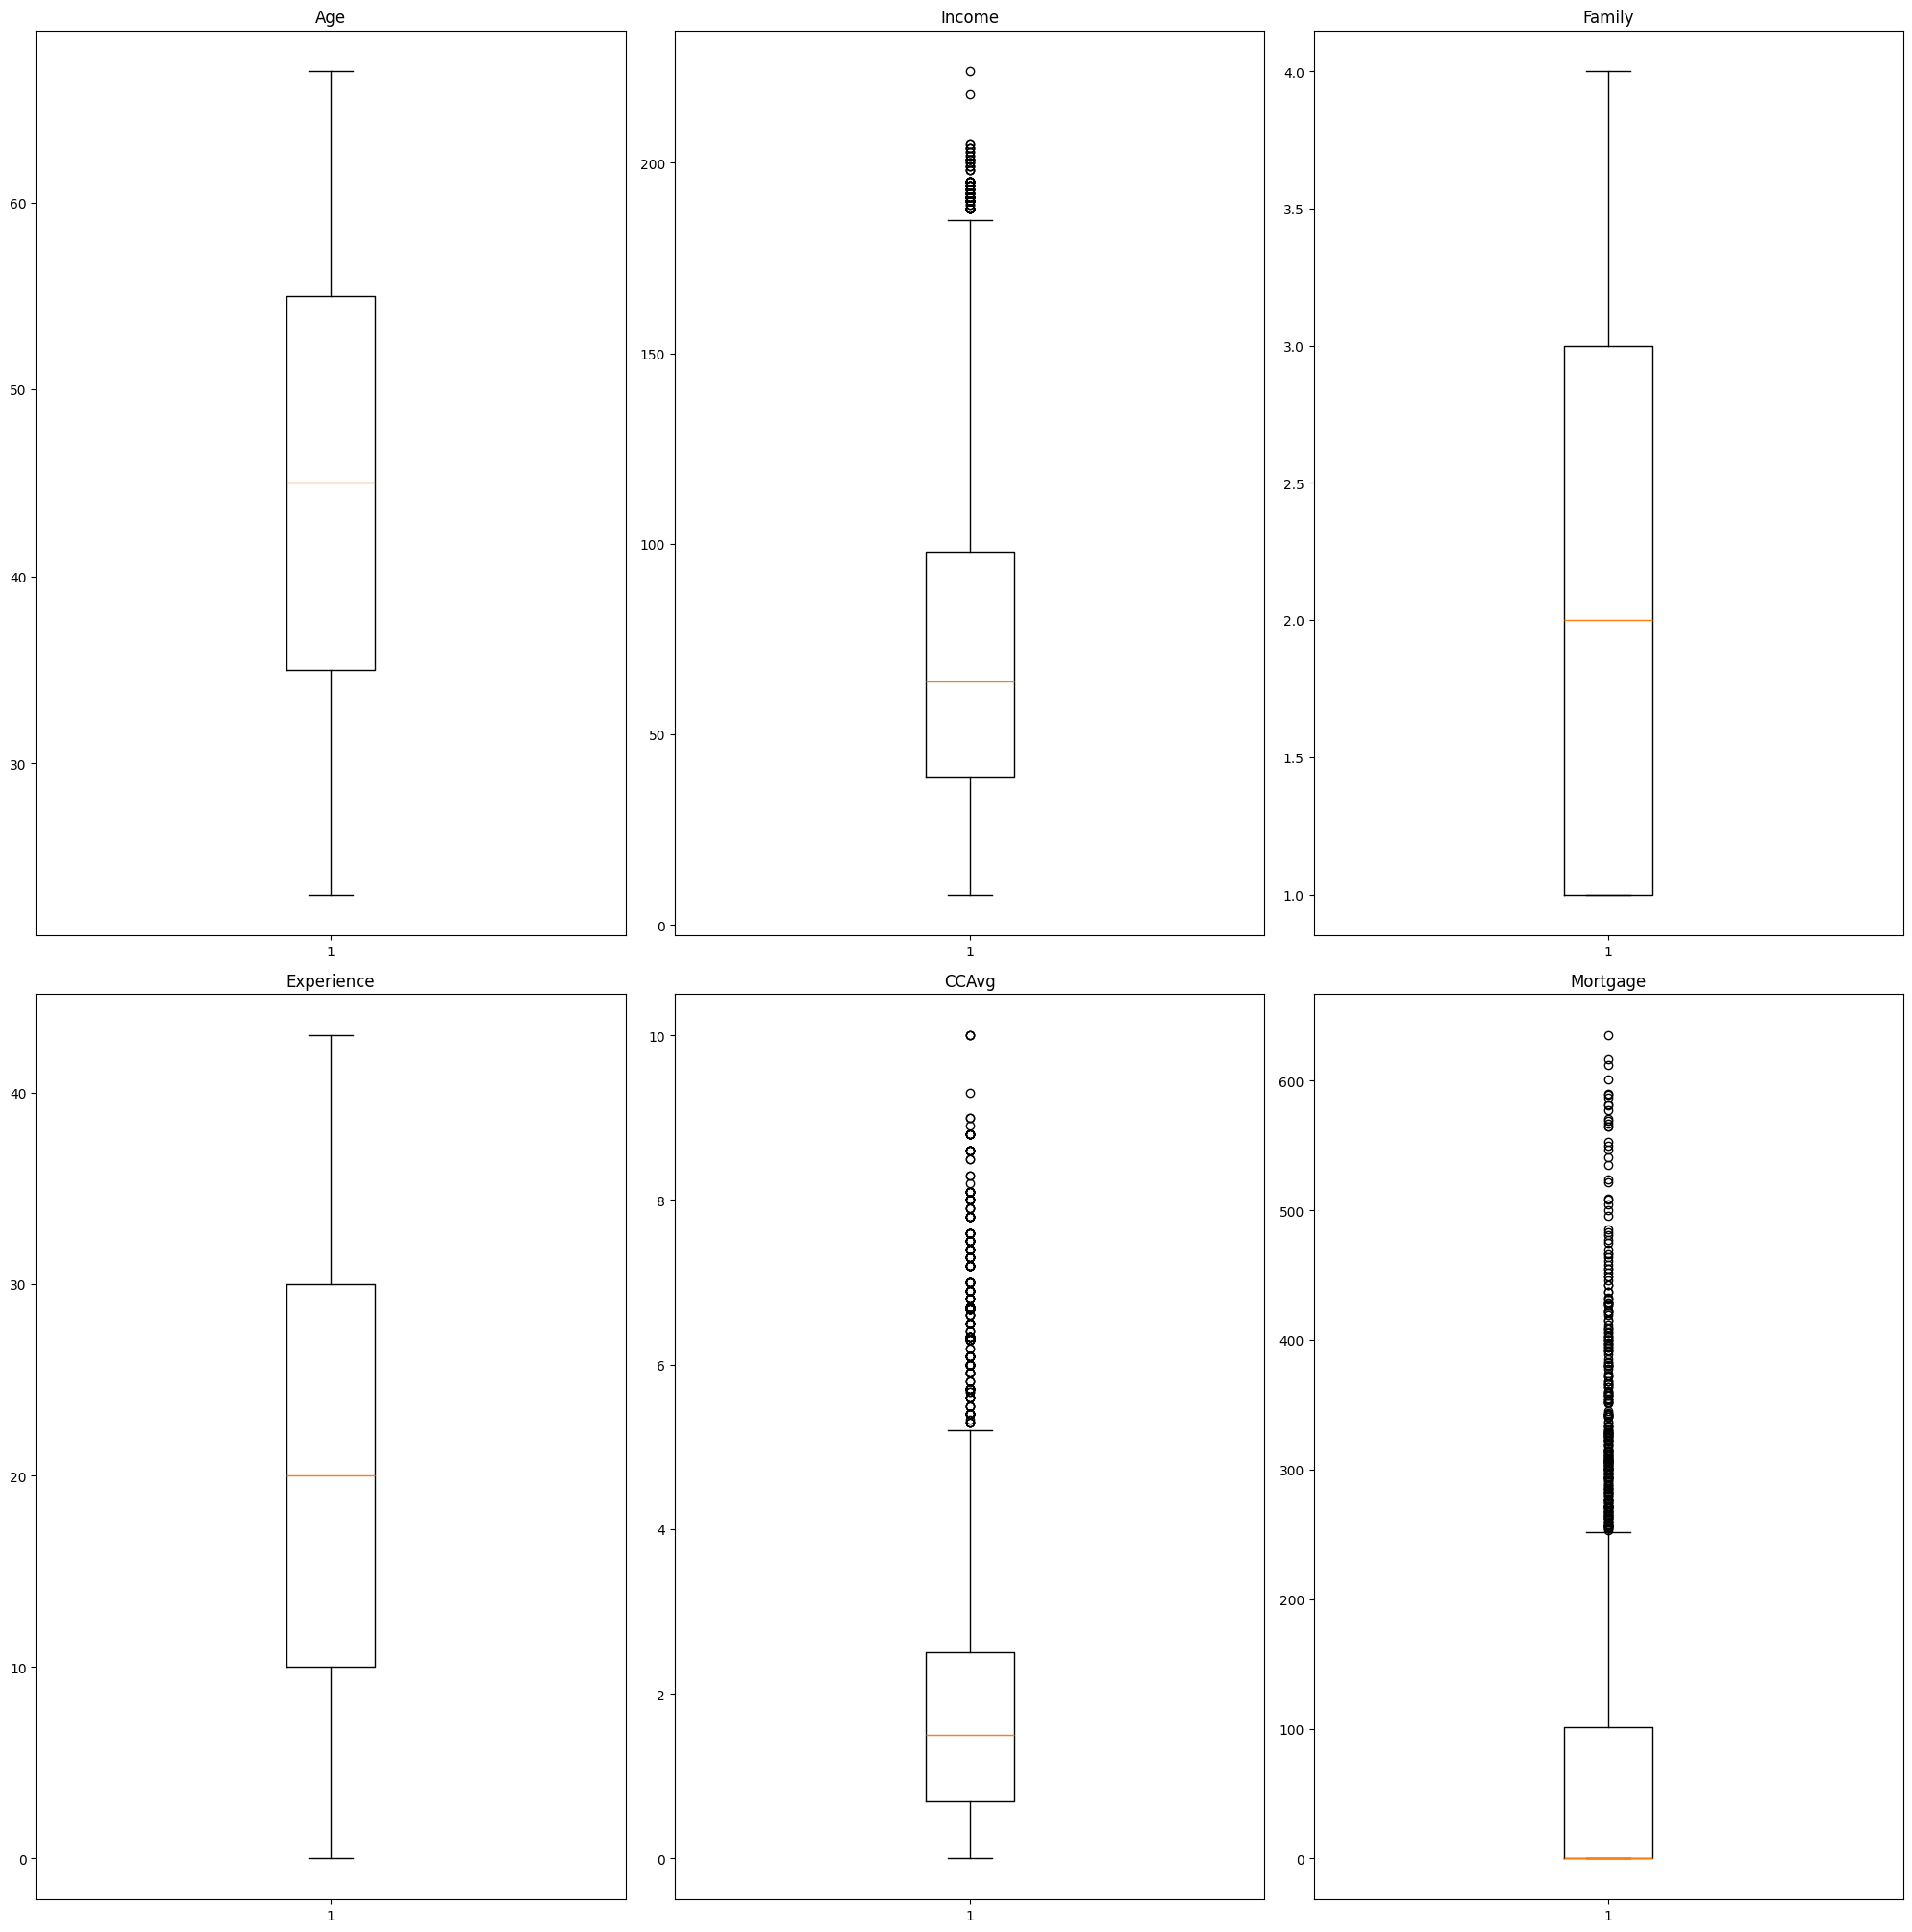

In [ ]:
#Code to see the numerical columns box plots
plt.figure(figsize=(20, 30))

for i, variable in enumerate(num_features):
    plt.subplot(3, 3, i + 1)
    plt.boxplot(data[variable], whis=1.5)
    plt.tight_layout()
    plt.title(variable)

plt.show()

In [ ]:
#Functions to treat outliers

def treat_outliers(df, col):

    Q1 = df[col].quantile(0.25)  # 25th quantile
    Q3 = df[col].quantile(0.75)  # 75th quantile
    IQR = Q3 - Q1
    Lower_Whisker = Q1 - 1.5 * IQR
    Upper_Whisker = Q3 + 1.5 * IQR

    # all the values smaller than Lower_Whisker will be assigned the value of Lower_Whisker
    # all the values greater than Upper_Whisker will be assigned the value of Upper_Whisker
    df[col] = np.clip(df[col], Lower_Whisker, Upper_Whisker)

    return df


def treat_outliers_all(df, col_list):

    for c in col_list:
        df = treat_outliers(df, c)

    return df

In [ ]:
#Treating all the numerical columns with ouliers
data = treat_outliers_all(data, num_features)

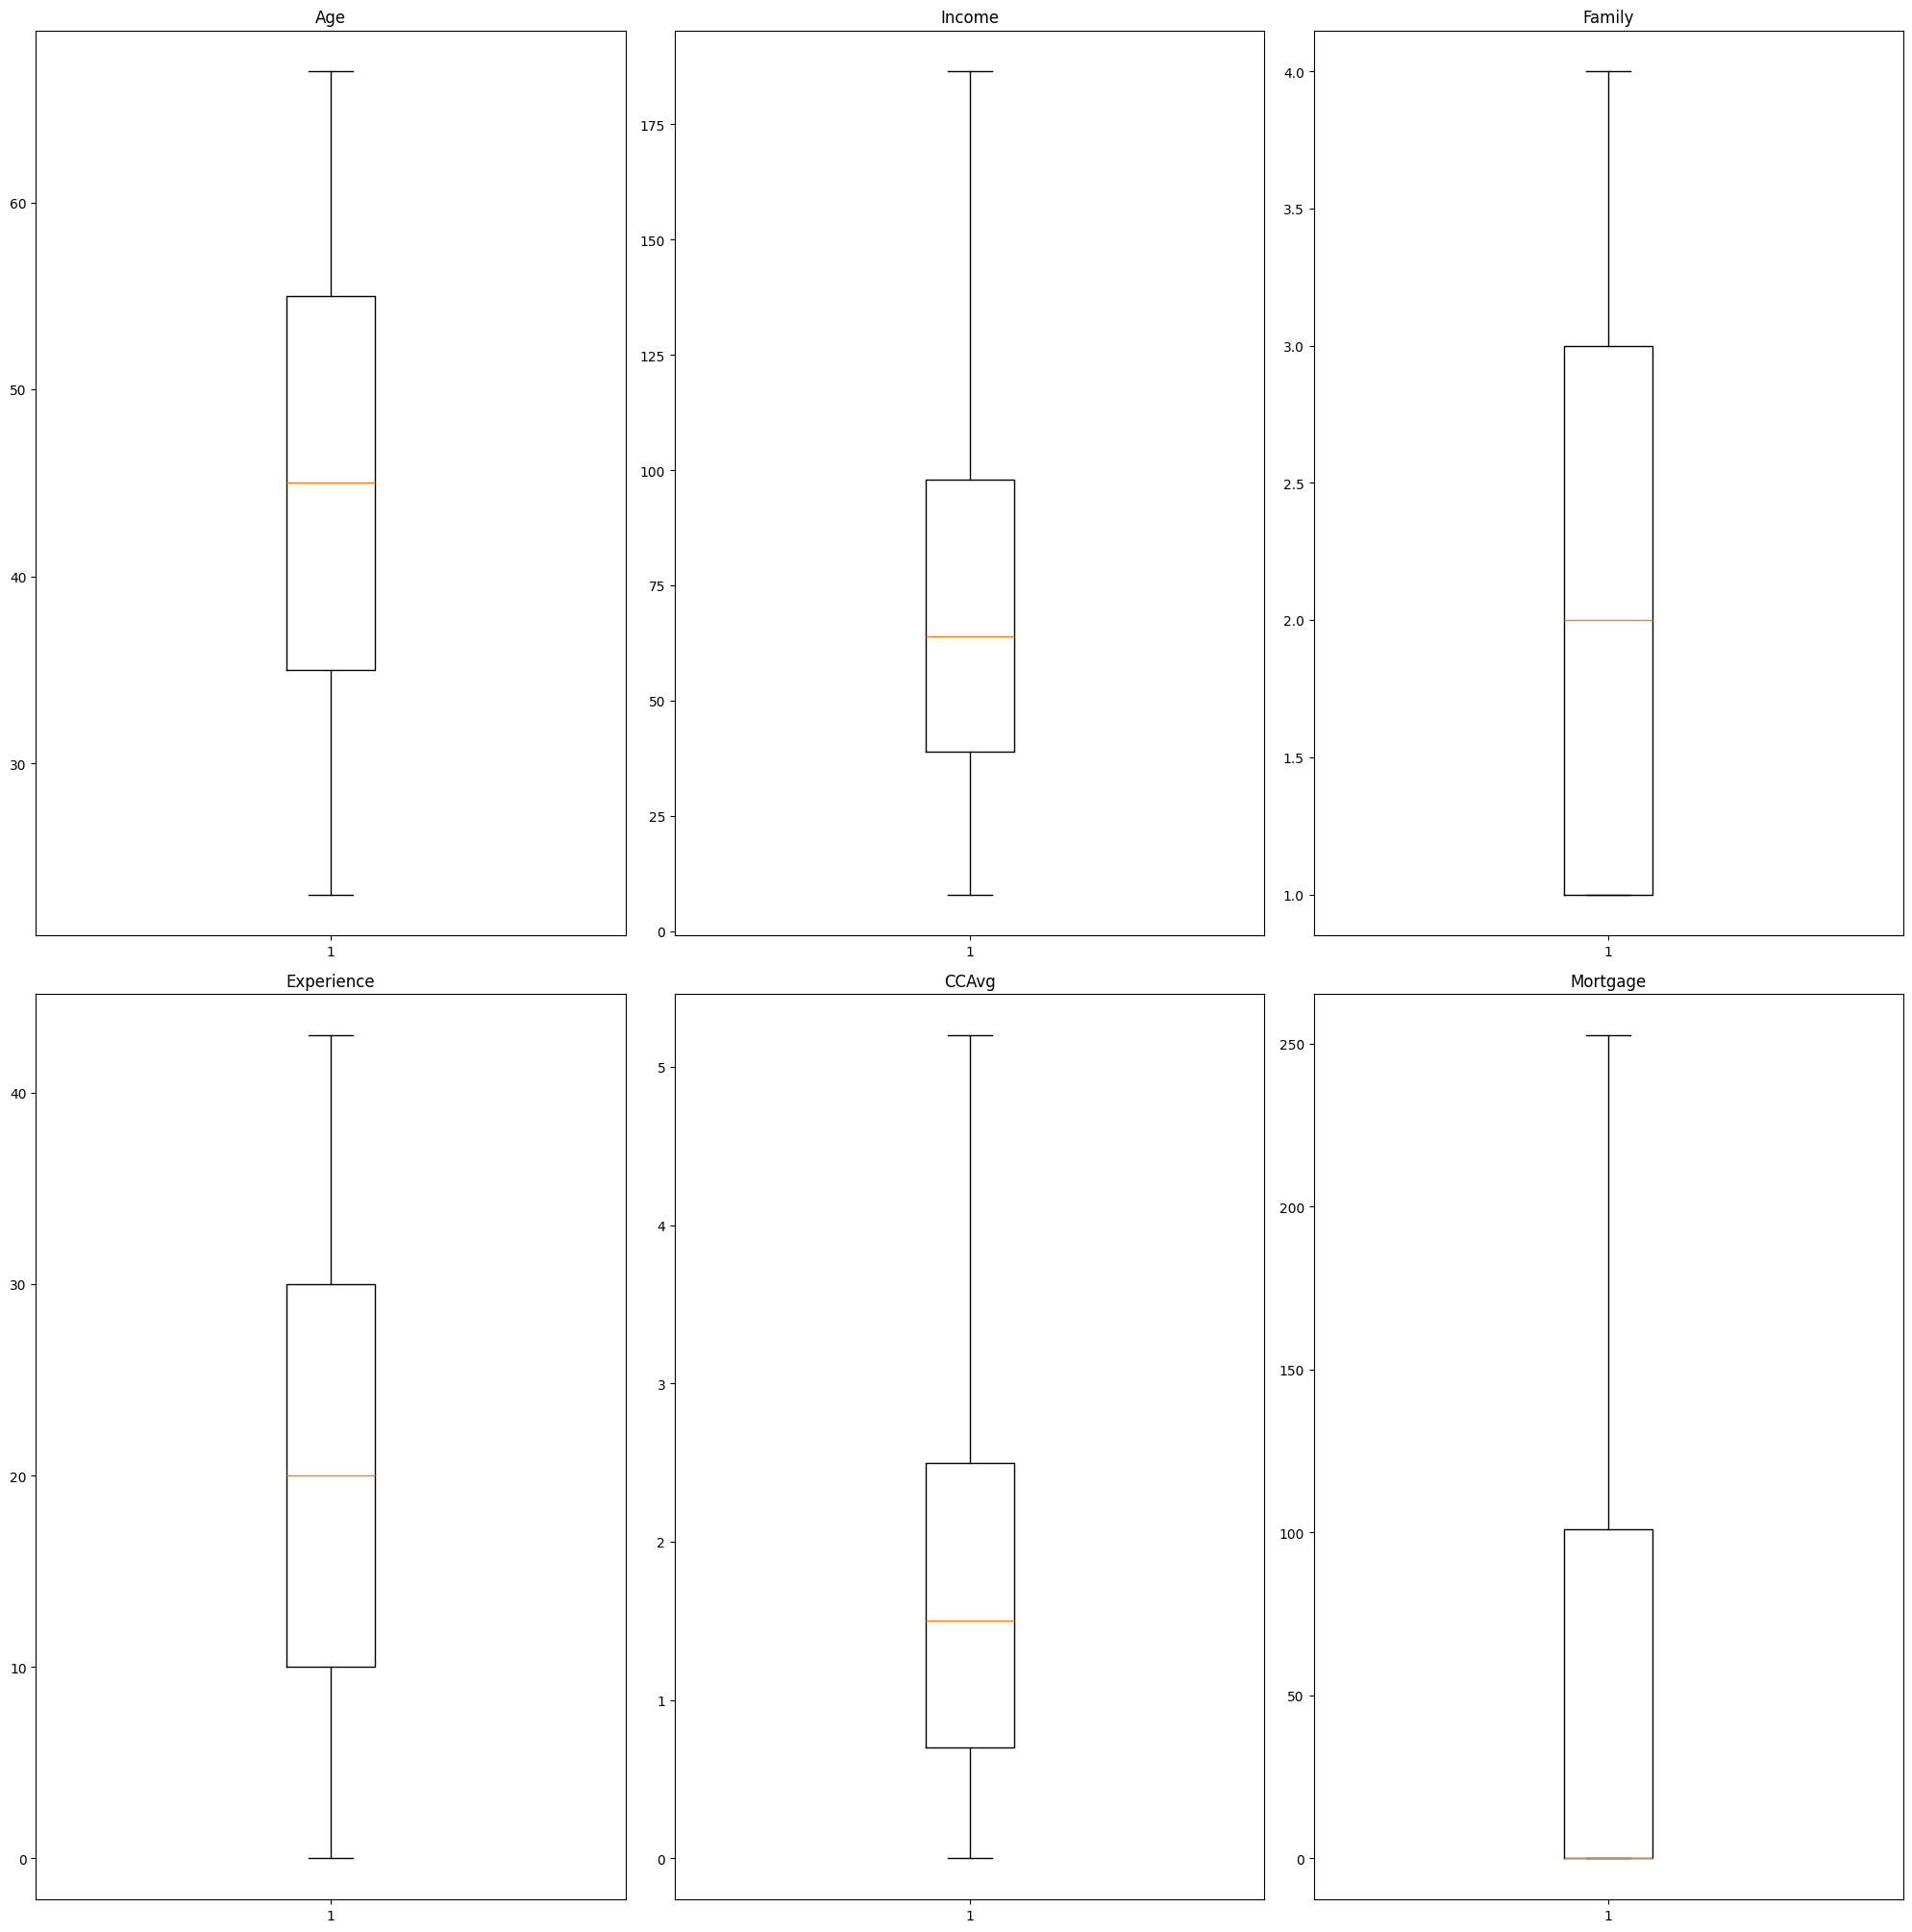

In [ ]:
# Code to check if outliers have been treated or not
plt.figure(figsize=(20, 30))

for i, variable in enumerate(num_features):
    plt.subplot(3, 3, i + 1)
    plt.boxplot(data[variable], whis=1.5)
    plt.tight_layout()
    plt.title(variable)

plt.show()

###Dropping Experience Column

*   Age and Experience have 0.99 correlation which means we can drop one of the columns from the data that we use to build the model.



In [ ]:
#Dropping the Experience and Perosnal Loan from the dataset.
X = data.drop(["Personal_Loan", "Experience"], axis=1)
Y = data["Personal_Loan"]

In [ ]:
# Creating dummies for ZipCode and Education Column
X = pd.get_dummies(X, columns=X.select_dtypes(include=['object', 'category']).columns, drop_first=True)

X = X.astype(float)

X.head()


,Age,Income,Family,CCAvg,Mortgage,ZIPCode_91,ZIPCode_92,ZIPCode_93,ZIPCode_94,ZIPCode_95,ZIPCode_96,Education_2,Education_3,Securities_Account_1,CD_Account_1,Online_1,CreditCard_1
0,25.0,49.0,4.0,1.6,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
1,45.0,34.0,3.0,1.5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
2,39.0,11.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,35.0,100.0,1.0,2.7,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
4,35.0,45.0,4.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0


###Splitting Data into Test & Training Sets

Splitting the training and test data into 80 and 20 percent.

In [ ]:
#Code to split the data
X_train, X_test, y_train, y_test = train_test_split(
    X, Y, test_size=0.20, random_state=3)

In [ ]:
print("Shape of Training set : ", X_train.shape)
print("Shape of test set : ", X_test.shape)
print("Percentage of classes in training set:")
print(y_train.value_counts(normalize=True))
print("Percentage of classes in test set:")
print(y_test.value_counts(normalize=True))

Shape of Training set :  (4000, 17)
Shape of test set :  (1000, 17)
Percentage of classes in training set:
Personal_Loan
0    0.90475
1    0.09525
Name: proportion, dtype: float64
Percentage of classes in test set:
Personal_Loan
0    0.901
1    0.099
Name: proportion, dtype: float64


*  We had seen that around 90% of observations belongs to class 0 (Not took a loan) and 9% observations belongs to class 1 (Took a loan), and this is preserved in the train and test sets

## Model Building

### Model Evaluation Criterion

A predictive model, such as a decision tree, can make wrong predictions in two ways:

**False Negative (FN)**: Predicting that a customer will not take a personal loan, but in reality, the customer does take the loan.

**False Positive (FP)**: Predicting that a customer will take a personal loan, but in reality, the customer does not take the loan.


**Which case is more important?**

If we predict that a customer will not take a loan but they actually do, the bank misses a marketing opportunity. This means marketing campaigns may not reach high-potential customers, resulting in lost interest income and missed profitability opportunities.

If we predict that a customer will take a loan but they actually don’t, the bank incurs marketing costs for outreach (emails, calls, or other campaigns). These costs are generally much lower than the potential revenue from successfully converting a customer.

**How to reduce losses?**

The bank should focus on maximizing recall in its predictive model.

Higher recall ensures that the model captures the majority of actual loan adopters, minimizing False Negatives.

### Model Building

####Decision Tree (default) Model0

In [ ]:
# creating an instance of the decision tree model
model0 = DecisionTreeClassifier(random_state=3)

# fitting the model to the training data
model0.fit(X_train, y_train)

DecisionTreeClassifier(random_state=3)

####Model Evaluation

Defining a utility function to collate all the metrics into a single data frame, and another to plot the confusion matrix.

In [ ]:
# defining a function to compute different metrics to check performance of a classification model built using sklearn
def model_performance_classification_sklearn(model, predictors, target):

    # predicting using the independent variables
    pred = model.predict(predictors)

    acc = accuracy_score(target, pred)  # to compute Accuracy
    recall = recall_score(target, pred)  # to compute Recall
    precision = precision_score(target, pred)  # to compute Precision
    f1 = f1_score(target, pred)  # to compute F1-score

    # creating a dataframe of metrics
    df_perf = pd.DataFrame(
        {"Accuracy": acc, "Recall": recall, "Precision": precision, "F1": f1,},
        index=[0],
    )

    return df_perf

In [ ]:
def confusion_matrix_sklearn(model, predictors, target):

    y_pred = model.predict(predictors)
    cm = confusion_matrix(target, y_pred)
    labels = np.asarray(
        [
            ["{0:0.0f}".format(item) + "\n{0:.2%}".format(item / cm.flatten().sum())]
            for item in cm.flatten()
        ]
    ).reshape(2, 2)

    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=labels, fmt="")
    plt.ylabel("True label")
    plt.xlabel("Predicted label")

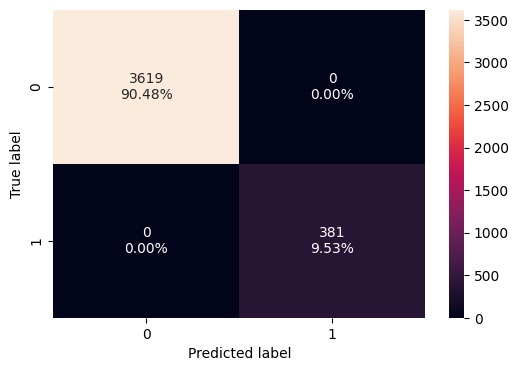

In [ ]:
#Plotting the confusion matrix for Training data of Model0
confusion_matrix_sklearn(model0, X_train, y_train)

In [ ]:
#Checking the values of evaluation metrics
decision_tree_default_perf_train = model_performance_classification_sklearn(model0, X_train, y_train)
decision_tree_default_perf_train

,Accuracy,Recall,Precision,F1
0,1.0,1.0,1.0,1.0


* Model is able to perfectly classify all the data points on the training set.
* 0 errors on the training set, each sample has been classified correctly.
* The model0 decision tree is overfitting to the training data.







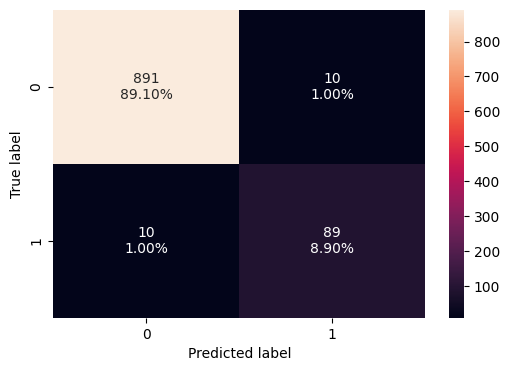

In [ ]:
#Plotting the confusion matrix for Testing data of Model0
confusion_matrix_sklearn(model0, X_test, y_test)

In [ ]:
#Checking the values of evaluation metrics
decision_tree_default_perf_test = model_performance_classification_sklearn(model0, X_test, y_test)
decision_tree_default_perf_test

,Accuracy,Recall,Precision,F1
0,0.98,0.89899,0.89899,0.89899


 * There is a difference in performance of model on training set and test set, which suggests that the model is overfiiting.

####Visualizing the Decision Tree

In [ ]:
#Creating a list of the training data features
feature_names = list(X_train.columns)
print(feature_names)

['Age', 'Income', 'Family', 'CCAvg', 'Mortgage', 'ZIPCode_91', 'ZIPCode_92', 'ZIPCode_93', 'ZIPCode_94', 'ZIPCode_95', 'ZIPCode_96', 'Education_2', 'Education_3', 'Securities_Account_1', 'CD_Account_1', 'Online_1', 'CreditCard_1']


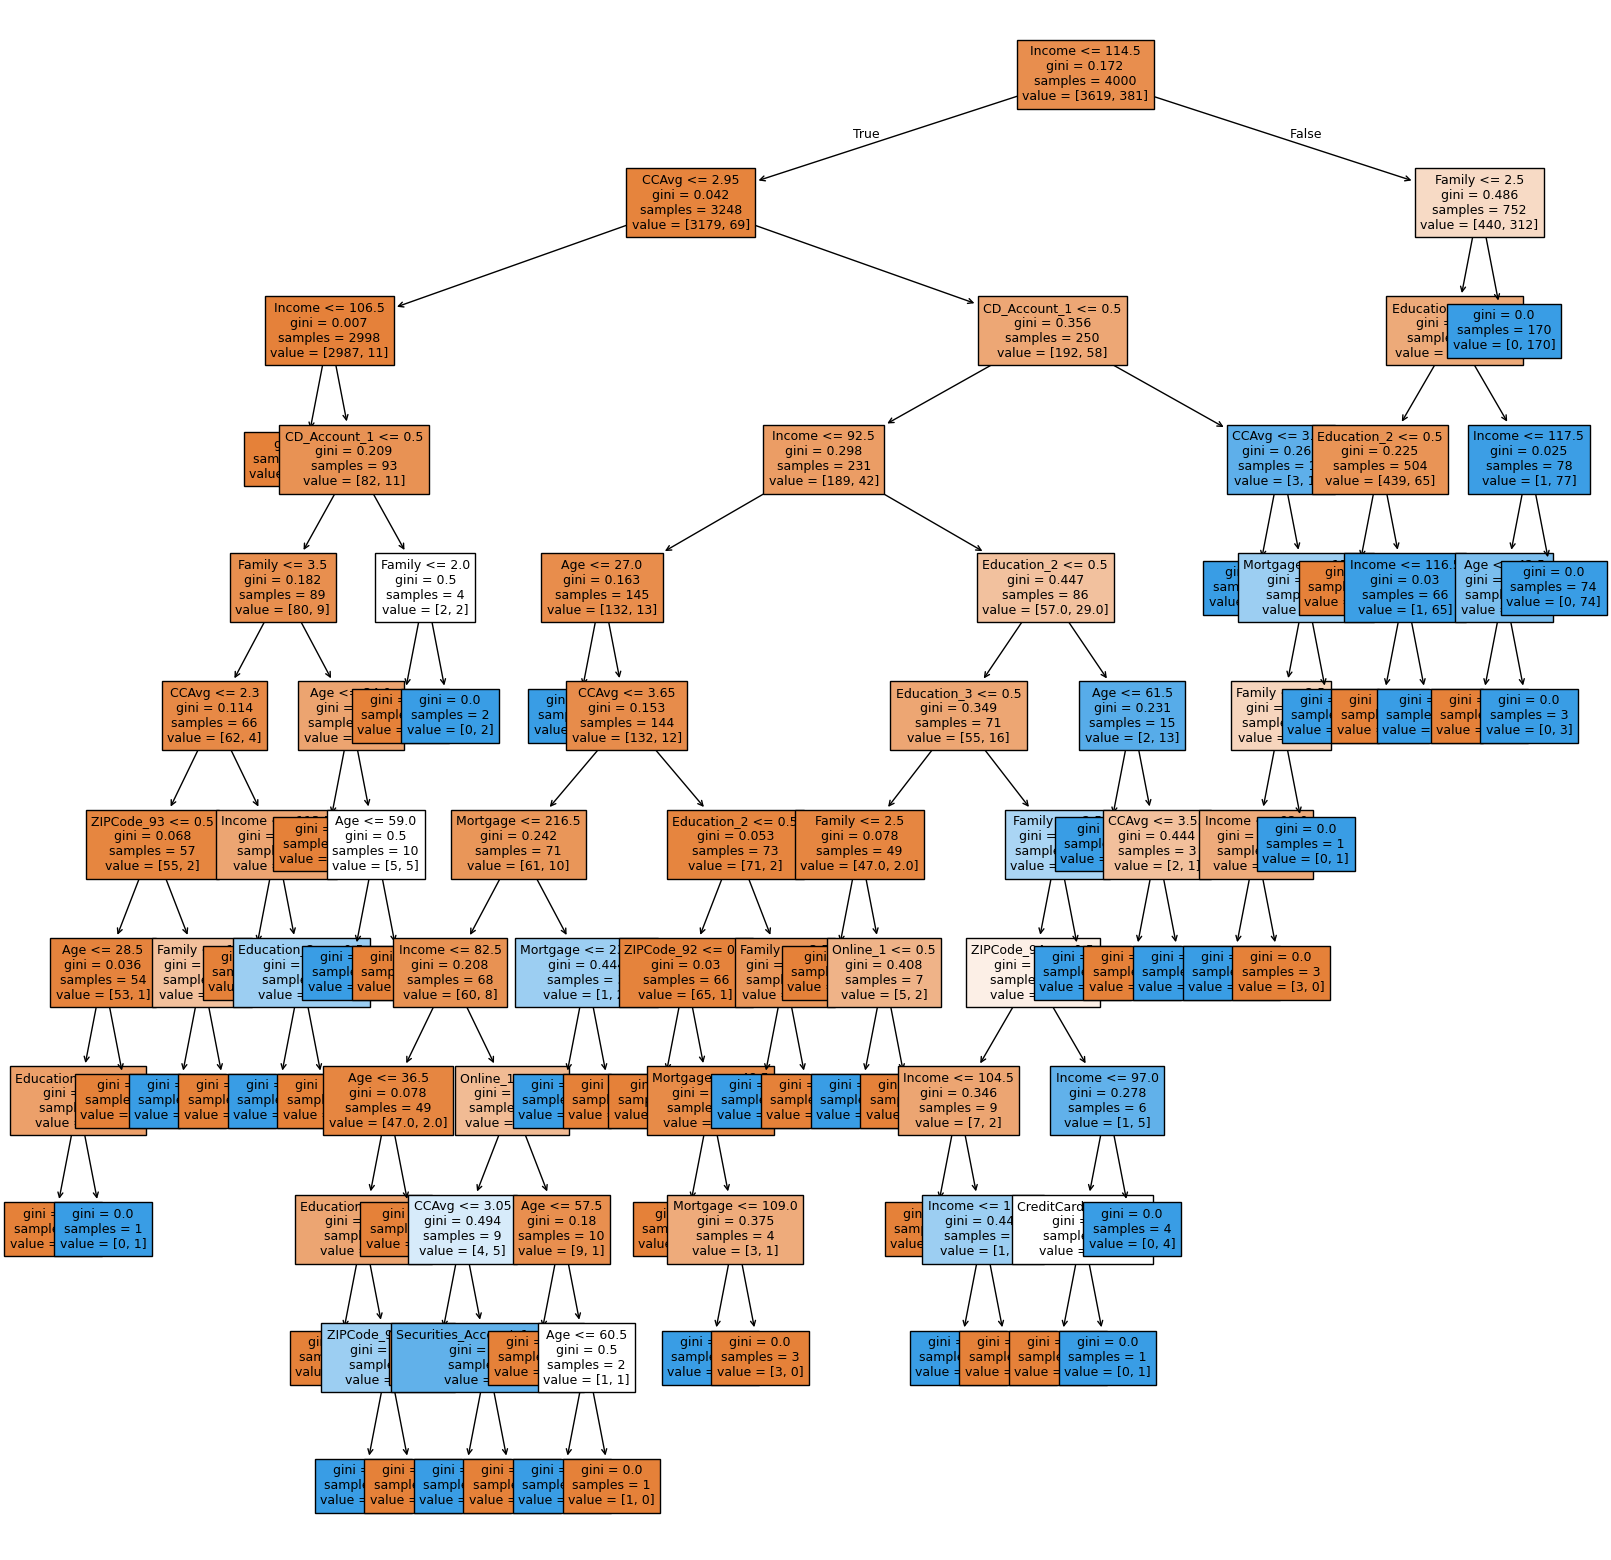

In [ ]:
# set the figure size for the plot
plt.figure(figsize=(20, 20))

# plotting the decision tree
out = tree.plot_tree(
    model0,                         # decision tree classifier model
    feature_names=feature_names,    # list of feature names (columns) in the dataset
    filled=True,                    # fill the nodes with colors based on class
    fontsize=9,                     # font size for the node text
    node_ids=False,                 # do not show the ID of each node
    class_names=None,               # whether or not to display class names
)

# add arrows to the decision tree splits if they are missing
for o in out:
    arrow = o.arrow_patch
    if arrow is not None:
        arrow.set_edgecolor("black")    # set arrow color to black
        arrow.set_linewidth(1)          # set arrow linewidth to 1

# displaying the plot
plt.show()

In [ ]:
# Text of the decisison tree
print(tree.export_text(model0, feature_names=feature_names, show_weights=True))

|--- Income <= 114.50
|   |--- CCAvg <= 2.95
|   |   |--- Income <= 106.50
|   |   |   |--- weights: [2905.00, 0.00] class: 0
|   |   |--- Income >  106.50
|   |   |   |--- CD_Account_1 <= 0.50
|   |   |   |   |--- Family <= 3.50
|   |   |   |   |   |--- CCAvg <= 2.30
|   |   |   |   |   |   |--- ZIPCode_93 <= 0.50
|   |   |   |   |   |   |   |--- Age <= 28.50
|   |   |   |   |   |   |   |   |--- Education_2 <= 0.50
|   |   |   |   |   |   |   |   |   |--- weights: [4.00, 0.00] class: 0
|   |   |   |   |   |   |   |   |--- Education_2 >  0.50
|   |   |   |   |   |   |   |   |   |--- weights: [0.00, 1.00] class: 1
|   |   |   |   |   |   |   |--- Age >  28.50
|   |   |   |   |   |   |   |   |--- weights: [49.00, 0.00] class: 0
|   |   |   |   |   |   |--- ZIPCode_93 >  0.50
|   |   |   |   |   |   |   |--- Family <= 1.50
|   |   |   |   |   |   |   |   |--- weights: [0.00, 1.00] class: 1
|   |   |   |   |   |   |   |--- Family >  1.50
|   |   |   |   |   |   |   |   |--- weights: [2.00,

*   We can observe that this is a very complex decision tree
*   Even though the test accuracy is high (0.98) with good precision and recall (0.89), the training performance is perfect (1.0 for all metrics), which suggests overfitting. The model may not perform as reliably on unseen data.



####Decisison Tree (Class Weight Balanced) Model 1

Since the majority of the customers did not take a loan, the model may become biased towards prediciting 0, because it is more frequent in the dataset. To overcome this issue, we will class weight = 'balanced' to assign high importance to the 1(Took a loan) class.

In [ ]:
#Creating a new Balanced Model
model1 = DecisionTreeClassifier(random_state=3, class_weight="balanced")
model1.fit(X_train, y_train)

DecisionTreeClassifier(class_weight='balanced', random_state=3)

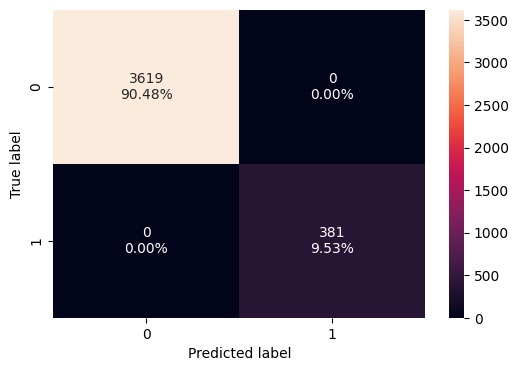

In [ ]:
#Plotting the confusion matrix for Training data of Model1
confusion_matrix_sklearn(model1, X_train, y_train)

In [ ]:
#Checking the values of evaluation metrics
decision_tree_perf_train = model_performance_classification_sklearn(model1, X_train, y_train)
decision_tree_perf_train

,Accuracy,Recall,Precision,F1
0,1.0,1.0,1.0,1.0


* Model is able to perfectly classify all the data points on the training set.
* 0 errors on the training set, each sample has been classified correctly.
* The model1 decision tree is overfitting to the training data.


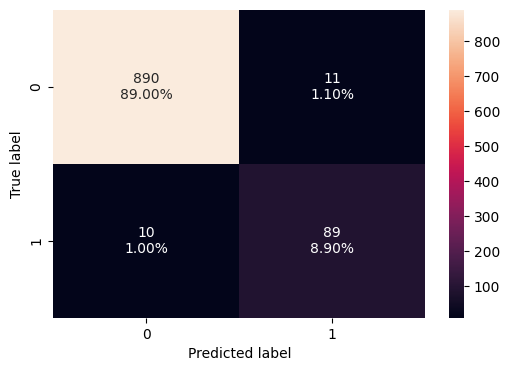

In [ ]:
#Plotting the confusion matrix for Testing data of Model1
confusion_matrix_sklearn(model1, X_test, y_test)

In [ ]:
#Checking the values of evaluation metrics
decision_tree_perf_test = model_performance_classification_sklearn(model1, X_test, y_test)
decision_tree_perf_test

,Accuracy,Recall,Precision,F1
0,0.979,0.89899,0.89,0.894472


There is a difference in performance of model on training set and test set, which suggests that the model is overfiiting.

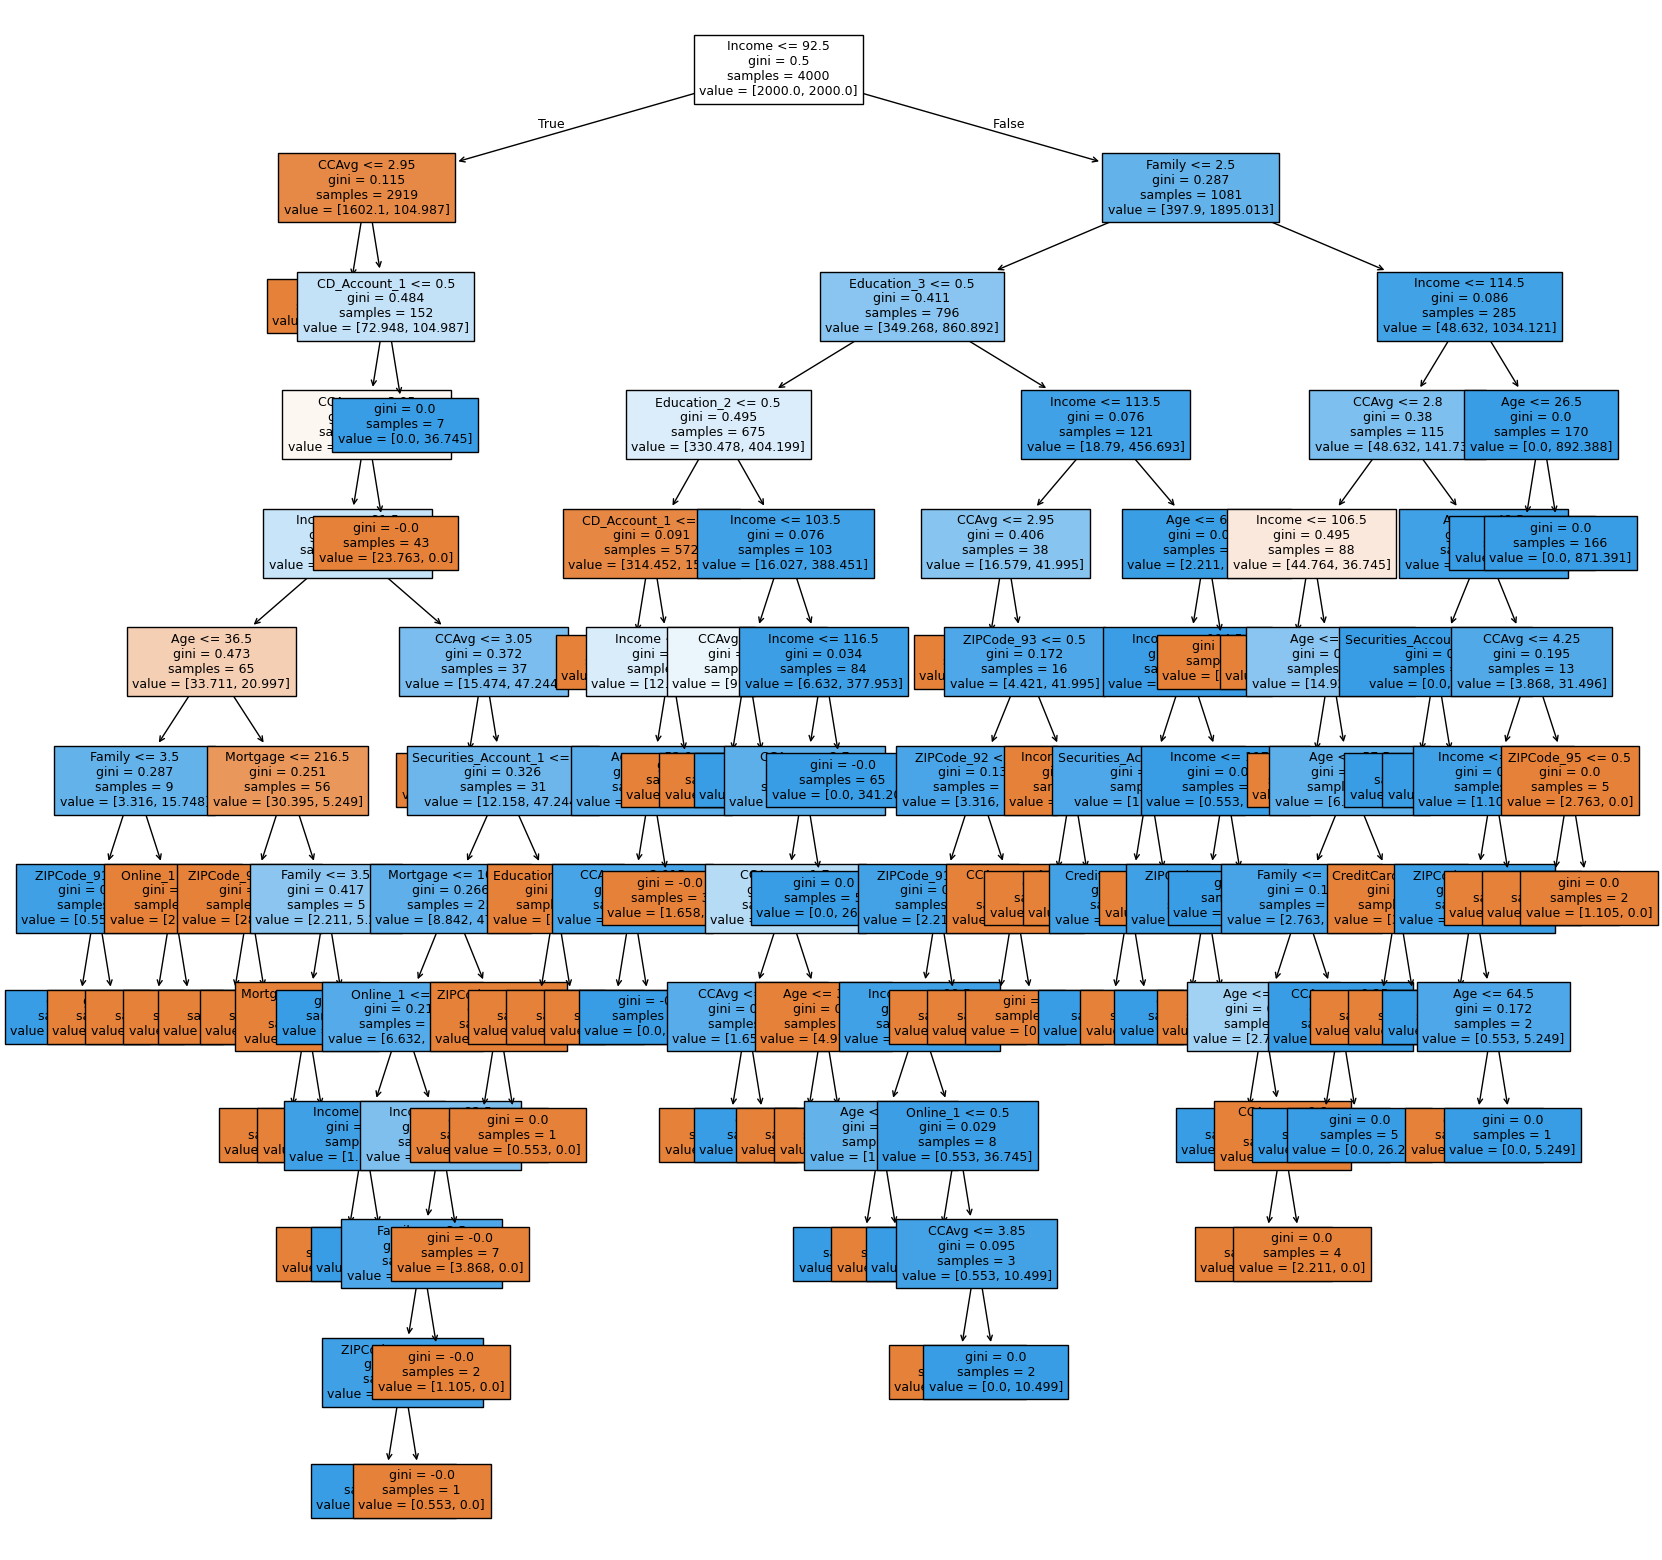

In [ ]:
# set the figure size for the plot
plt.figure(figsize=(20, 20))

# plotting the decision tree
out = tree.plot_tree(
    model1,                         # decision tree classifier model
    feature_names=feature_names,    # list of feature names (columns) in the dataset
    filled=True,                    # fill the nodes with colors based on class
    fontsize=9,                     # font size for the node text
    node_ids=False,                 # do not show the ID of each node
    class_names=None,               # whether or not to display class names
)

# add arrows to the decision tree splits if they are missing
for o in out:
    arrow = o.arrow_patch
    if arrow is not None:
        arrow.set_edgecolor("black")    # set arrow color to black
        arrow.set_linewidth(1)          # set arrow linewidth to 1

# displaying the plot
plt.show()

*   We can observe that this is a very complex decision tree
*   This model behaves similarly to the default tree and still shows perfect training performance, meaning overfitting remains.



## Model Performance Improvement

####Decision Tree (Pre-puring) Model 2

In [ ]:
# Define the parameters of the tree to iterate over
max_depth_values = np.arange(2, 7, 2)
max_leaf_nodes_values = [50, 75, 150, 250]
min_samples_split_values = [10, 30, 50, 70]

# Initialize variables to store the best model and its performance
best_estimator = None
best_score_diff = float('inf')
best_test_score = 0.0

# Iterate over all combinations of the specified parameter values
for max_depth in max_depth_values:
    for max_leaf_nodes in max_leaf_nodes_values:
        for min_samples_split in min_samples_split_values:

            # Initialize the tree with the current set of parameters
            estimator = DecisionTreeClassifier(
                max_depth=max_depth,
                max_leaf_nodes=max_leaf_nodes,
                min_samples_split=min_samples_split,
                class_weight='balanced',
                random_state=3
            )

            # Fit the model to the training data
            estimator.fit(X_train, y_train)

            # Make predictions on the training and test sets
            y_train_pred = estimator.predict(X_train)
            y_test_pred = estimator.predict(X_test)

            # Calculate recall scores for training and test sets
            train_recall_score = recall_score(y_train, y_train_pred)
            test_recall_score = recall_score(y_test, y_test_pred)

            # Calculate the absolute difference between training and test recall scores
            score_diff = abs(train_recall_score - test_recall_score)

            # Update the best estimator and best score if the current one has a smaller score difference
            if (score_diff < best_score_diff) & (test_recall_score > best_test_score):
                best_score_diff = score_diff
                best_test_score = test_recall_score
                best_estimator = estimator

# Print the best parameters
print("Best parameters found:")
print(f"Max depth: {best_estimator.max_depth}")
print(f"Max leaf nodes: {best_estimator.max_leaf_nodes}")
print(f"Min samples split: {best_estimator.min_samples_split}")
print(f"Best test recall score: {best_test_score}")

Best parameters found:
Max depth: 2
Max leaf nodes: 50
Min samples split: 10
Best test recall score: 1.0


In [ ]:
# creating an instance of the best model
model2 = best_estimator

# fitting the best model to the training data
model2.fit(X_train, y_train)

DecisionTreeClassifier(class_weight='balanced', max_depth=np.int64(2),
                       max_leaf_nodes=50, min_samples_split=10, random_state=3)

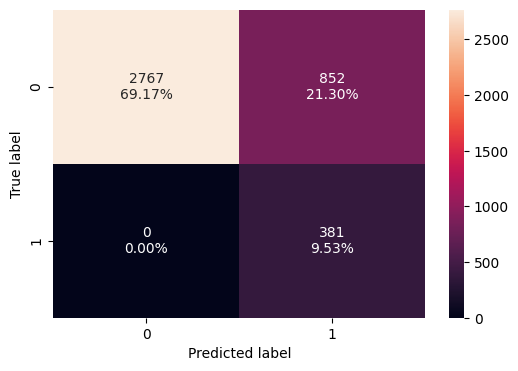

In [ ]:
#Plotting the confusion matrix for Training data of Model2
confusion_matrix_sklearn(model2, X_train, y_train)

In [ ]:
#Checking the values of evaluation metrics
decision_tree_tune_perf_train = model_performance_classification_sklearn(model2, X_train, y_train)
decision_tree_tune_perf_train

,Accuracy,Recall,Precision,F1
0,0.787,1.0,0.309002,0.472119


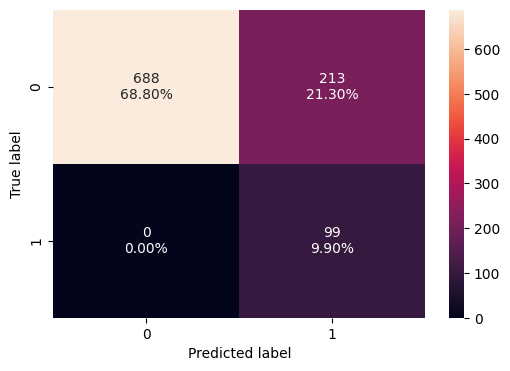

In [ ]:
#Plotting the confusion matrix for Testing data of Model2
confusion_matrix_sklearn(model2, X_test, y_test)

In [ ]:
#Checking the values of evaluation metrics
decision_tree_tune_perf_test = model_performance_classification_sklearn(model2, X_test, y_test)
decision_tree_tune_perf_test

,Accuracy,Recall,Precision,F1
0,0.787,1.0,0.317308,0.481752


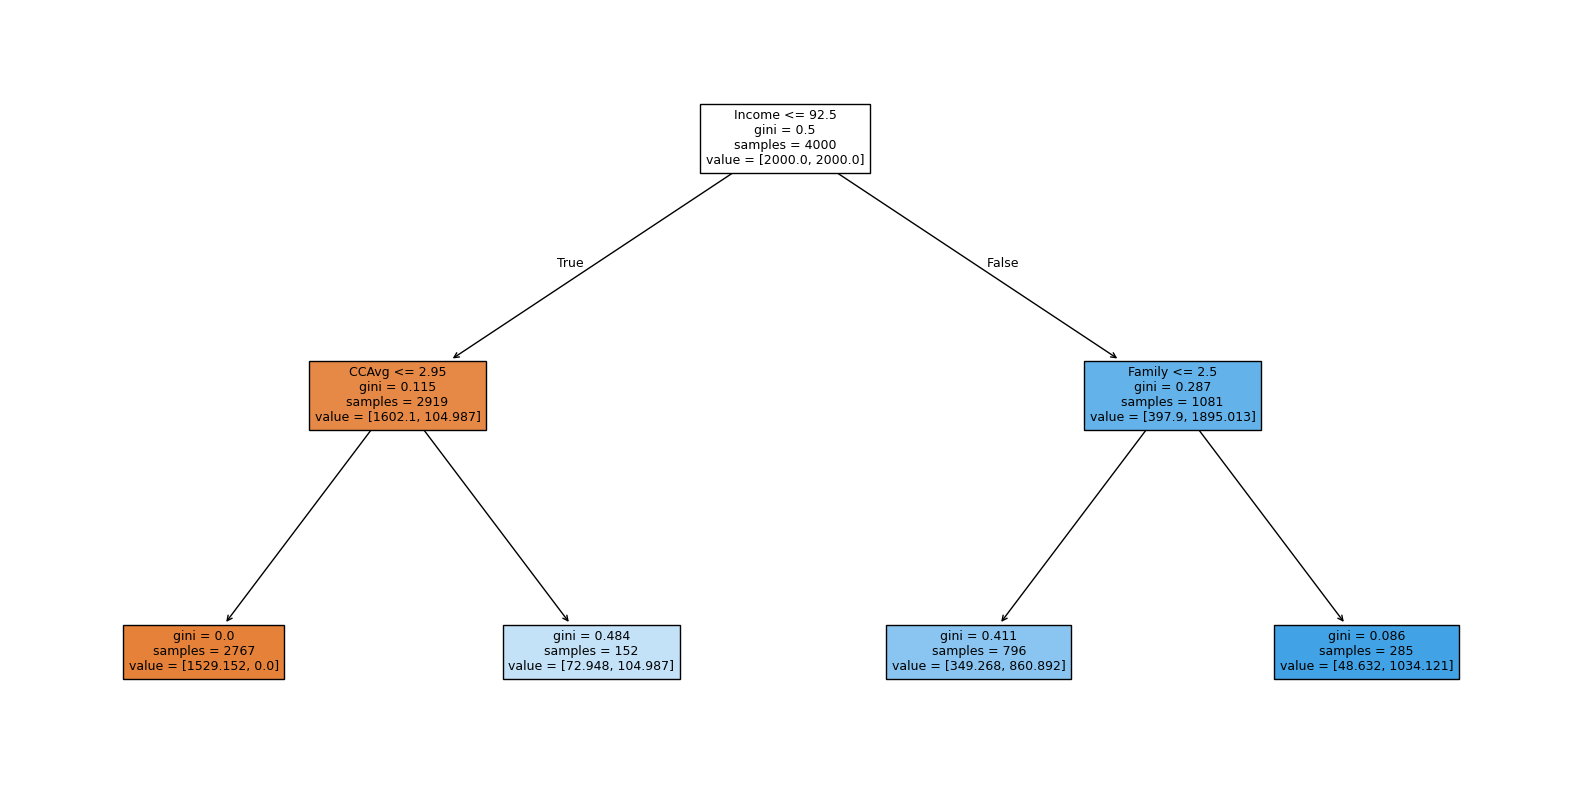

In [ ]:
plt.figure(figsize=(20, 10))
out = tree.plot_tree(
    model2,
    feature_names=feature_names,
    filled=True,
    fontsize=9,
    node_ids=False,
    class_names=None,
)
# below code will add arrows to the decision tree split if they are missing
for o in out:
    arrow = o.arrow_patch
    if arrow is not None:
        arrow.set_edgecolor("black")
        arrow.set_linewidth(1)
plt.show()

In [ ]:
# Text report showing the rules of a decision tree -
print(tree.export_text(model2, feature_names=feature_names, show_weights=True))

|--- Income <= 92.50
|   |--- CCAvg <= 2.95
|   |   |--- weights: [1529.15, 0.00] class: 0
|   |--- CCAvg >  2.95
|   |   |--- weights: [72.95, 104.99] class: 1
|--- Income >  92.50
|   |--- Family <= 2.50
|   |   |--- weights: [349.27, 860.89] class: 1
|   |--- Family >  2.50
|   |   |--- weights: [48.63, 1034.12] class: 1



The model achieves perfect recall, meaning it identifies all customers who are likely to take a personal loan and avoids missing potential borrowers. However, the low precision (31%) indicates many customers predicted to take a loan do not actually convert, leading to more marketing outreach. Since training and test results are very similar, the model generalizes well and is not overfitting.

The tree suggests that the best target customers for personal loan campaigns are:

*   High-income customers (Income > 92.5)
*   Moderate income customers with high credit card spending (CCAvg > 2.95)

Customers with low income and low credit card usage are unlikely to convert.

In [ ]:
#Code to see the important features from Model2
importances = model2.feature_importances_
importances

array([0.        , 0.86492394, 0.05126237, 0.08381369, 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        ])

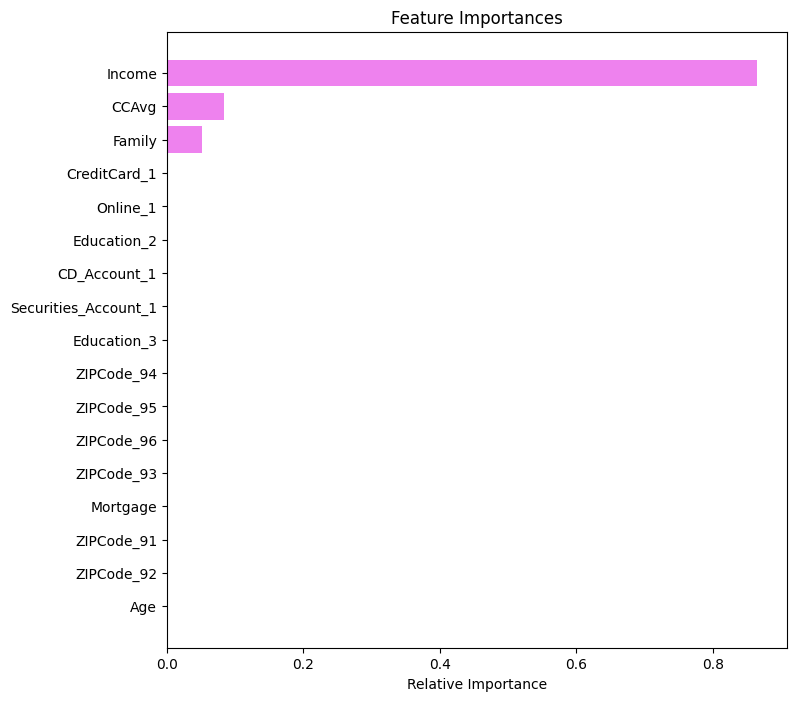

In [ ]:
#Plotting importance features from Model2

importances = model2.feature_importances_
indices = np.argsort(importances)

plt.figure(figsize=(8, 8))
plt.title("Feature Importances")
plt.barh(range(len(indices)), importances[indices], color="violet", align="center")
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel("Relative Importance")
plt.show()

*   In the pre pruned decision tree, income is the most impotant feature.*   CCAvg (Credit casrd usage) & Family size are also slighly important features.





####Decision Tree (Post-Pruning) Model 3

In [ ]:
#Create an instance of the decision tree model
clf = DecisionTreeClassifier(random_state=3, class_weight="balanced")

#Compute the cost complexity pruning path for the model using the training data
path = clf.cost_complexity_pruning_path(X_train, y_train)

# Extract the array of effective alphas from the pruning path and total impurities at each alpha along the pruning path
ccp_alphas, impurities = abs(path.ccp_alphas), path.impurities

In [ ]:
pd.DataFrame(path)

,ccp_alphas,impurities
0,0.000000e+00,-2.372012e-16
1,3.067762e-19,-2.368944e-16
2,4.141479e-19,-2.364802e-16
3,4.601643e-19,-2.360201e-16
4,4.601643e-19,-2.355599e-16
5,2.622574e-18,-2.329373e-16
6,3.129117e-18,-2.298082e-16
7,3.129117e-18,-2.266791e-16
8,4.693676e-18,-2.219854e-16
9,5.706037e-18,-2.162794e-16


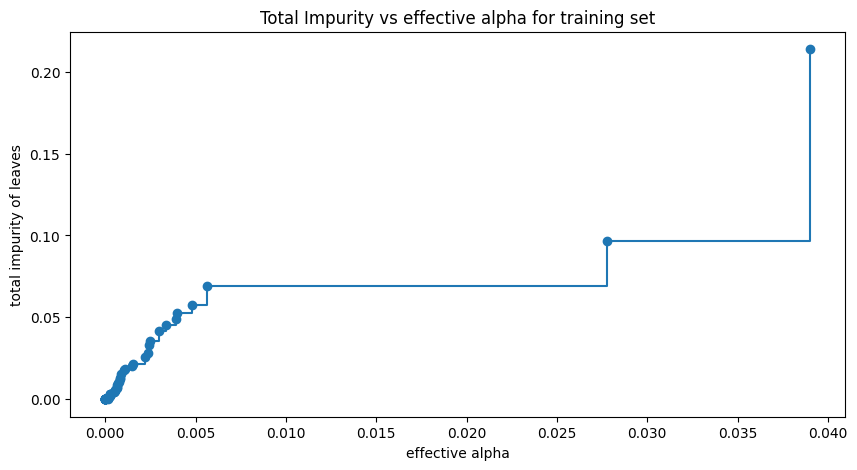

In [ ]:
#Plotting total impurities Vs Effective Alpha for training set
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(ccp_alphas[:-1], impurities[:-1], marker="o", drawstyle="steps-post")
ax.set_xlabel("effective alpha")
ax.set_ylabel("total impurity of leaves")
ax.set_title("Total Impurity vs effective alpha for training set")
plt.show()

- Next, we train a decision tree using the effective alphas.

- The last value in ccp_alphas is the alpha value that prunes the whole tree,
leaving the corresponding tree with one node.

In [ ]:
#Code to get the number of nodes in the last tree along with its ccp_alpha value
clfs = []
for ccp_alpha in ccp_alphas:
    clf = DecisionTreeClassifier(
        random_state=3, ccp_alpha=ccp_alpha, class_weight="balanced"
    )
    clf.fit(X_train, y_train)
    clfs.append(clf)
print(
    "Number of nodes in the last tree is: {} with ccp_alpha: {}".format(
        clfs[-1].tree_.node_count, ccp_alphas[-1]
    )
)

Number of nodes in the last tree is: 1 with ccp_alpha: 0.28630967865546936


* Moving ahead, we remove the last element in clfs and ccp_alphas as it corresponds to a trivial tree with only one node.



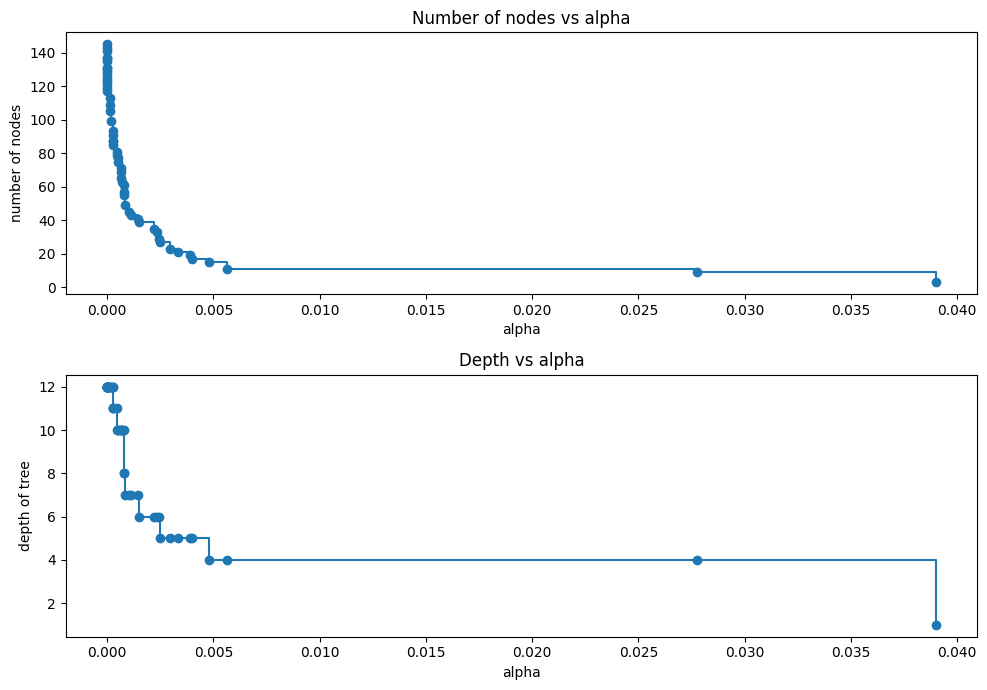

In [ ]:
#Plotting Alpha with depth & No of nodes
clfs = clfs[:-1]
ccp_alphas = ccp_alphas[:-1]

node_counts = [clf.tree_.node_count for clf in clfs]
depth = [clf.tree_.max_depth for clf in clfs]
fig, ax = plt.subplots(2, 1, figsize=(10, 7))
ax[0].plot(ccp_alphas, node_counts, marker="o", drawstyle="steps-post")
ax[0].set_xlabel("alpha")
ax[0].set_ylabel("number of nodes")
ax[0].set_title("Number of nodes vs alpha")
ax[1].plot(ccp_alphas, depth, marker="o", drawstyle="steps-post")
ax[1].set_xlabel("alpha")
ax[1].set_ylabel("depth of tree")
ax[1].set_title("Depth vs alpha")
fig.tight_layout()

#####Recall vs alpha for training and testing sets

In [ ]:
recall_train = []
for clf in clfs:
    pred_train = clf.predict(X_train)
    values_train = recall_score(y_train, pred_train)
    recall_train.append(values_train)

In [ ]:
recall_test = []
for clf in clfs:
    pred_test = clf.predict(X_test)
    values_test = recall_score(y_test, pred_test)
    recall_test.append(values_test)

In [ ]:
train_scores = [clf.score(X_train, y_train) for clf in clfs]
test_scores = [clf.score(X_test, y_test) for clf in clfs]

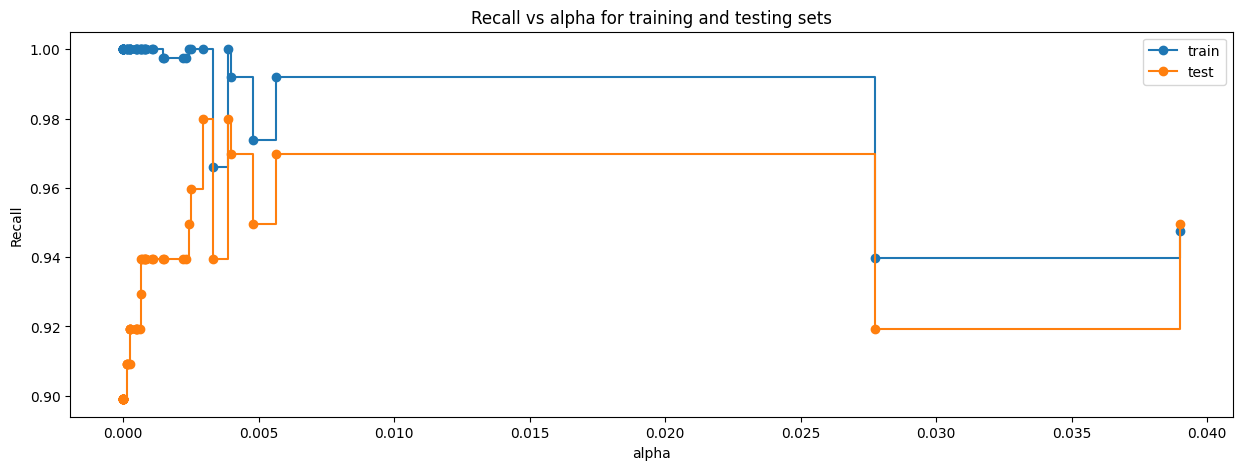

In [ ]:
#Plotting recall vs Alpha for Training and Testing sets
fig, ax = plt.subplots(figsize=(15, 5))
ax.set_xlabel("alpha")
ax.set_ylabel("Recall")
ax.set_title("Recall vs alpha for training and testing sets")
ax.plot(
    ccp_alphas, recall_train, marker="o", label="train", drawstyle="steps-post",
)
ax.plot(ccp_alphas, recall_test, marker="o", label="test", drawstyle="steps-post")
ax.legend()
plt.show()

In [ ]:
# creating the model where we get highest train and test recall
index_best_model = np.argmax(recall_test)
best_model = clfs[index_best_model]
print(best_model)

DecisionTreeClassifier(ccp_alpha=np.float64(0.0029620925316465414),
                       class_weight='balanced', random_state=3)


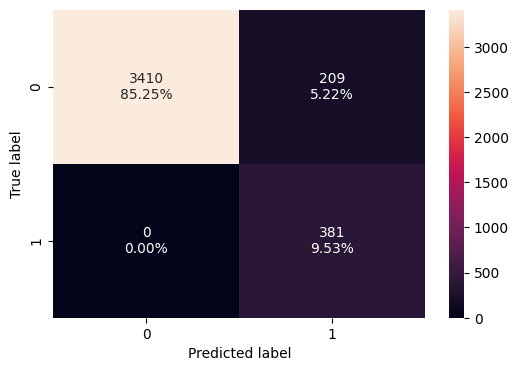

In [ ]:
#Plotting the confusion matrix for Training data of Model3
model3 = best_model
confusion_matrix_sklearn(model3, X_train, y_train)

In [ ]:
#Checking the values of evaluation metrics
decision_tree_post_perf_train = model_performance_classification_sklearn(model3, X_train, y_train)
decision_tree_post_perf_train

,Accuracy,Recall,Precision,F1
0,0.94775,1.0,0.645763,0.784758


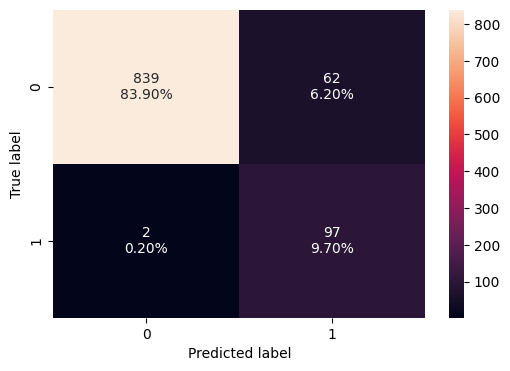

In [ ]:
#Plotting the confusion matrix for Testing data of Model3
confusion_matrix_sklearn(model3, X_test, y_test)

In [ ]:
#Checking the values of evaluation metrics
decision_tree_post_test = model_performance_classification_sklearn(model3, X_test, y_test)
decision_tree_post_test

,Accuracy,Recall,Precision,F1
0,0.936,0.979798,0.610063,0.751938


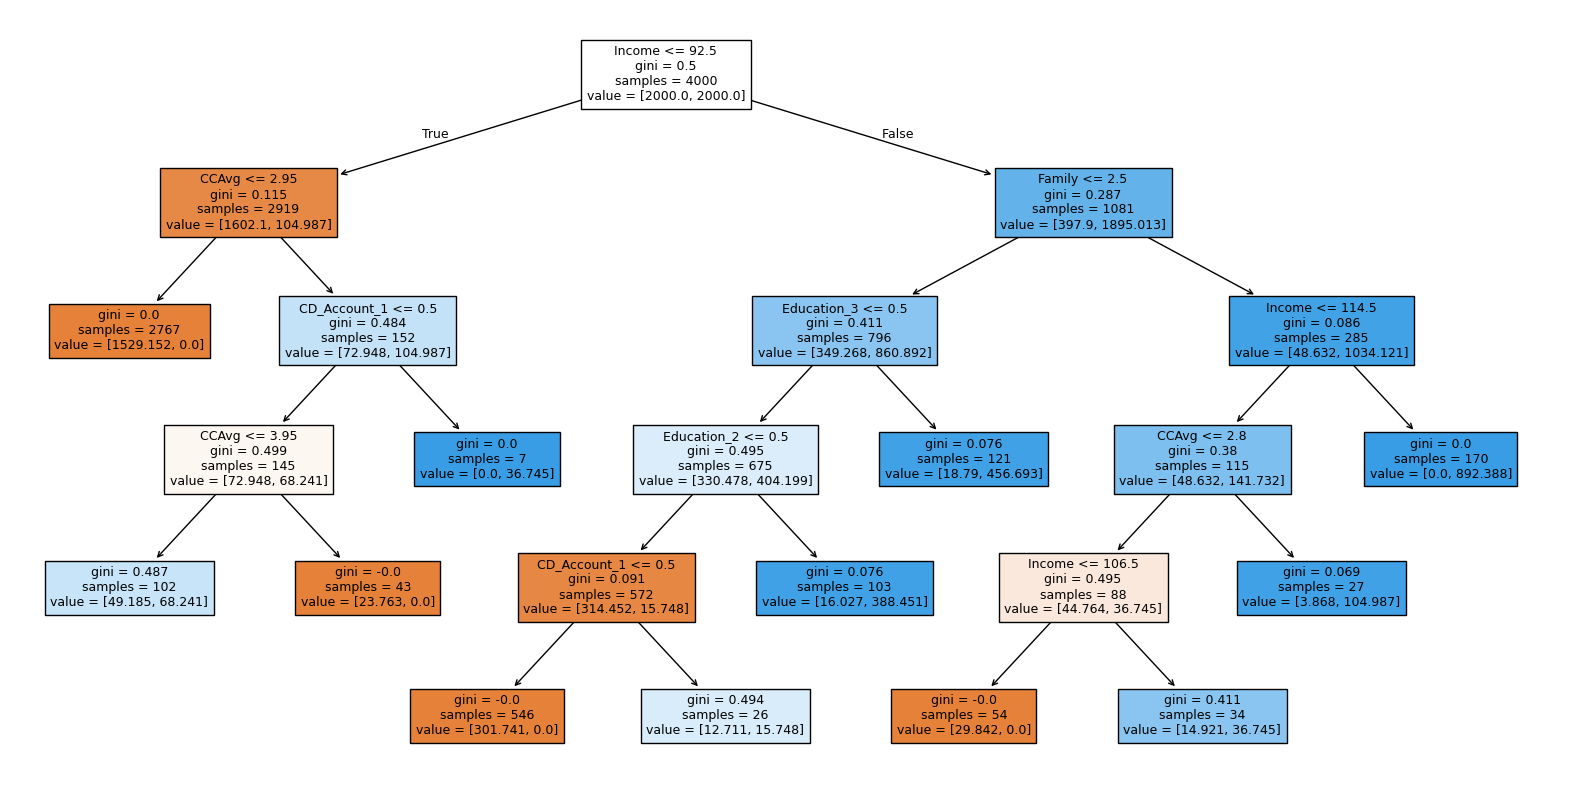

In [ ]:
#Visualizing Model3 Decision Tree
plt.figure(figsize=(20, 10))

out = tree.plot_tree(
    model3,
    feature_names=feature_names,
    filled=True,
    fontsize=9,
    node_ids=False,
    class_names=None,
)
for o in out:
    arrow = o.arrow_patch
    if arrow is not None:
        arrow.set_edgecolor("black")
        arrow.set_linewidth(1)
plt.show()

In [ ]:
# Text report showing the rules of a decision tree -

print(tree.export_text(model3, feature_names=feature_names, show_weights=True))

|--- Income <= 92.50
|   |--- CCAvg <= 2.95
|   |   |--- weights: [1529.15, 0.00] class: 0
|   |--- CCAvg >  2.95
|   |   |--- CD_Account_1 <= 0.50
|   |   |   |--- CCAvg <= 3.95
|   |   |   |   |--- weights: [49.18, 68.24] class: 1
|   |   |   |--- CCAvg >  3.95
|   |   |   |   |--- weights: [23.76, 0.00] class: 0
|   |   |--- CD_Account_1 >  0.50
|   |   |   |--- weights: [0.00, 36.75] class: 1
|--- Income >  92.50
|   |--- Family <= 2.50
|   |   |--- Education_3 <= 0.50
|   |   |   |--- Education_2 <= 0.50
|   |   |   |   |--- CD_Account_1 <= 0.50
|   |   |   |   |   |--- weights: [301.74, 0.00] class: 0
|   |   |   |   |--- CD_Account_1 >  0.50
|   |   |   |   |   |--- weights: [12.71, 15.75] class: 1
|   |   |   |--- Education_2 >  0.50
|   |   |   |   |--- weights: [16.03, 388.45] class: 1
|   |   |--- Education_3 >  0.50
|   |   |   |--- weights: [18.79, 456.69] class: 1
|   |--- Family >  2.50
|   |   |--- Income <= 114.50
|   |   |   |--- CCAvg <= 2.80
|   |   |   |   |--- Inc

The model shows strong performance with high accuracy (93%) and very high recall (97%) ensuring most potential loan customers are correctly identified. Precision (61%) indicates that a majority of predicted loan customers actually convert, improving marketing efficiency. The similar training and test results suggest the model generalizes well without overfitting.

In [ ]:
#Code to get the important features from Model3
importances = model3.feature_importances_
indices = np.argsort(importances)

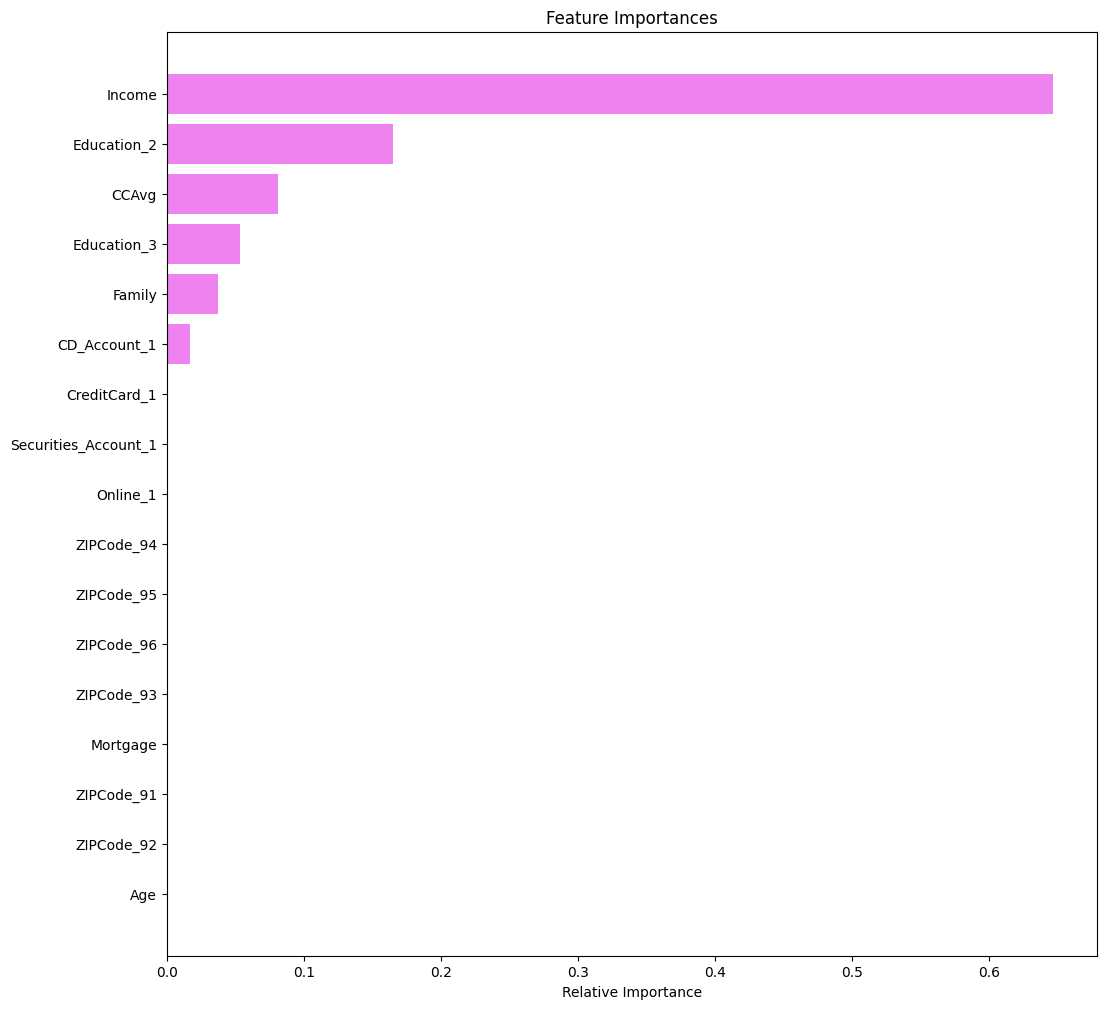

In [ ]:
#Plotting the important features from Model3
plt.figure(figsize=(12, 12))
plt.title("Feature Importances")
plt.barh(range(len(indices)), importances[indices], color="violet", align="center")
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel("Relative Importance")
plt.show()

*  Income is the most important feature in the post pruned tree.
*  Eduaction 2 (Graduate) customers have the next importance. Followed by CCAvg and Eduaction 3(Advanced/Professional). It makes in a way, as customers with high degree have high paying jobs, leading to higher chnace of taking a personal loan.



## Model Performance Comparison and Final Model Selection

In [ ]:
# training performance comparison

models_train_comp_df = pd.concat(
    [
        decision_tree_default_perf_train.T,
        decision_tree_perf_train.T,
        decision_tree_tune_perf_train.T,
        decision_tree_post_perf_train.T,
    ],
    axis=1,
)
models_train_comp_df.columns = [
    "Decision Tree (sklearn default)",
    "Decision Tree with class_weight",
    "Decision Tree (Pre-Pruning)",
    "Decision Tree (Post-Pruning)",
]
print("Training performance comparison:")
models_train_comp_df

Training performance comparison:


,Decision Tree (sklearn default),Decision Tree with class_weight,Decision Tree (Pre-Pruning),Decision Tree (Post-Pruning)
Accuracy,1.0,1.0,0.787000,0.947750
Recall,1.0,1.0,1.000000,1.000000
Precision,1.0,1.0,0.309002,0.645763
F1,1.0,1.0,0.472119,0.784758


In [ ]:
# testing performance comparison

models_test_comp_df = pd.concat(
    [
        decision_tree_default_perf_test.T,
        decision_tree_perf_test.T,
        decision_tree_tune_perf_test.T,
        decision_tree_post_test.T,
    ],
    axis=1,
)
models_test_comp_df.columns = [
    "Decision Tree (sklearn default)",
    "Decision Tree with class_weight",
    "Decision Tree (Pre-Pruning)",
    "Decision Tree (Post-Pruning)",
]
print("Test set performance comparison:")
models_test_comp_df

Test set performance comparison:


,Decision Tree (sklearn default),Decision Tree with class_weight,Decision Tree (Pre-Pruning),Decision Tree (Post-Pruning)
Accuracy,0.98000,0.979000,0.787000,0.936000
Recall,0.89899,0.898990,1.000000,0.979798
Precision,0.89899,0.890000,0.317308,0.610063
F1,0.89899,0.894472,0.481752,0.751938


The post-pruned decision tree is the most suitable model because it balances recall and precision while reducing overfitting, allowing the bank to identify most potential loan customers while keeping marketing efforts reasonably efficient.

## Actionable Insights and Business Recommendations


* The bank can use the existing customer base to identify customers who might be likely to take a personal loan.
*  The model built has a 97% recall meaning it can be used to correctly predict whether an existing customer is likely to take a personal loan.
*  Income, credit card spending (CCAvg), Higher Education and family size are the most important variables influencing personal loan adoption.
* The bank should target customers with high income (around 92K) and high CCAvg Spending (around 3k) and offer them pre-approved loan offers.
*  The bank should assign a probability score (will take a loan) for every customer and focus on customers who have a probabity more than 50-60%.
*   The bank can also reduce marketing costs by limiting outreach to customers with low income and low credit card spending, as they are less likely to take a personal loan.
*  The bank should continue collecting more customer data and update the model continuously to improve accuracy and campaingn effectiveness.






___